# Nexus Sentinel — Detección de Uso Indebido de Credenciales
## UEBA sobre datos reales de Los Alamos National Laboratory

Este notebook construye, de principio a fin, un sistema de puntuación de riesgo por **usuario-día**
para detectar el uso indebido de credenciales legítimas (cuenta comprometida o insider) sobre los
logs reales de autenticación de la red corporativa interna de LANL, usando los ataques reales de un
red team profesional como ground truth. Es el entregable reproducible del proyecto: narra cada
decisión metodológica e importa la lógica desde los módulos de `src/` (el código de producción vive
ahí; el notebook es la evidencia y la narrativa).

**Cómo reproducirlo (doble ruta, sección 6.1 del plan):**
1. *Regeneración completa desde la fuente* (lenta, opcional): descarga los 7.2 GB desde csr.lanl.gov
   y repite el muestreo completo. Se activa con `REGENERATE = True`.
2. *Carga del Parquet de trabajo* (rápida, ruta por defecto): usa el dataset de trabajo ya muestreado
   y documentado (~209 MB).

**Estructura:** 1) Adquisición y muestreo · 2) EDA · 3) Ingeniería de variables · 4) Modelado y
evaluación · 5) Pipeline e inferencia.

### Preparación del entorno

Esta celda deja el entorno listo para importar los módulos del proyecto. En Google Colab hay que
clonar primero el repositorio e instalar las dependencias (líneas comentadas); en ejecución local
basta con agregar la raíz del repositorio al path de Python, porque el notebook vive en `notebook/`
y los módulos en `src/`. Si la celda corre sin errores, el entorno está completo.

In [1]:
# En Colab: descomentar las tres líneas siguientes
# !git clone https://github.com/<usuario>/nexus-sentinel.git
# %cd nexus-sentinel
# !pip install -q -r requirements.txt

import sys
sys.path.insert(0, '..')  # ejecutar desde notebook/ en local

from src import data, eda

## 1. Adquisición y muestreo (Fase 1)

**Fuente de datos:** Kent, A. D. (2015). *Comprehensive, Multi-Source Cyber-Security Events*
[Data set]. Los Alamos National Laboratory. https://csr.lanl.gov/data/cyber1/ (DOI: 10.17021/1179829).
Son 58 días consecutivos de eventos desidentificados de una red corporativa real: 1,648,275,307
eventos en 5 fuentes, 12,425 usuarios y 17,684 computadoras. Usamos dos archivos: `auth.txt.gz`
(7.2 GB comprimido, ~1,051 millones de autenticaciones Windows/AD — la fuente principal) y
`redteam.txt.gz` (4.8 KB — los eventos de compromiso reales que sirven de etiquetas).

**Nota de adquisición (2026):** el sitio ya no ofrece descarga directa anónima; antepone un
*data fence* que solicita email y uso declarado, y devuelve un token de descarga
(`src/data.py::request_download_token`). Cada descarga queda documentada (fecha UTC, URL, tamaño)
en `data/raw/*.download.json`, como exige la sección 2.2 del plan.

### El muestreo es la decisión metodológica clave (sección 2.3 del plan)

Mil millones de eventos no caben en Colab ni hacen falta: el volumen se gestiona con un muestreo
**documentado y justificado, no ocultado** (decisión de diseño nº 5). Las reglas y su justificación:

- **Ventana temporal: primeros 30 días.** Justificación empírica: el 100% de los eventos del red team
  ocurre entre los días 1 y 29, así que la ventana conserva todo el ground truth.
- **Usuarios: los 104 comprometidos + 4,000 normales.** Se incluyen TODAS las cuentas que aparecen en
  `redteam.txt` y una muestra aleatoria de usuarios normales con semilla fija (`SEED = 42`),
  estratificada por cuartil de actividad para no sesgar la línea base hacia cuentas hiperactivas ni
  casi inactivas.
- **Exclusión de cuentas no humanas.** Las cuentas de máquina (terminan en `$`) y de sistema (SYSTEM,
  Local Service, Network Service, ANONYMOUS LOGON) se excluyen del universo muestreable: el scoring
  es sobre personas.
- **Regla de retención de eventos:** se conserva un evento si `src_user` **o** `dst_user` está en la
  muestra — las features de cadenas de saltos (sección 4.2) necesitan ver al usuario también como
  destino.
- **Calidad documentada:** `redteam.txt` trae 749 líneas crudas de las cuales 12 líneas distintas
  aparecen duplicadas (34 filas extra); se deduplica a 715 eventos únicos.

**Limitación documentada de la fuente (sesgo de `auth.txt`):** LANL solo incluye eventos de fallo
de usuarios que tuvieron al menos un éxito en algún punto del dataset — las cuentas que únicamente
fallaron (p. ej. fuerza bruta contra cuentas inexistentes) no aparecen en el archivo. No es un
problema "limpiable": son filas que no existen, y cualquier imputación fabricaría datos. Su efecto
sobre este proyecto es acotado por diseño: el objetivo es detectar **credenciales válidas usadas
indebidamente** (el atacante autentica con éxito), no ataques de adivinación contra cuentas
inexistentes, que quedan explícitamente fuera del alcance. Se documenta aquí y en el análisis de
limitaciones del documento final.

### Ruta 1 (opcional y lenta): regeneración completa desde la fuente

Esta celda reproduce la Fase 1 completa: solicita el token al *data fence* de LANL, descarga ambos
archivos en streaming (sin descomprimir los ~70 GB a disco: la lectura es por chunks sobre el archivo
comprimido) y ejecuta el muestreo descrito arriba. Tarda 1–2 horas, dominadas por la descarga de
7.2 GB; por eso está desactivada por defecto (`REGENERATE = False`). Al ejecutarla imprime el
diccionario de conteos que se verifica más abajo. Requiere declarar un email en `EMAIL`.

In [2]:
REGENERATE = False

if REGENERATE:
    EMAIL = ''   # requerido por el data fence de LANL
    USAGE = 'Academic data science course project: user behavior analytics / anomaly detection research'
    token = data.request_download_token(EMAIL, USAGE)
    for fname in ('redteam.txt.gz', 'auth.txt.gz'):
        data.download_streaming(fname, '../data/raw', token)
    meta = data.build_working_sample('../data/raw/auth.txt.gz', '../data/raw/redteam.txt.gz',
                                     out_dir='../data/work')
    print(meta['counts'])

### Obtención del Parquet de trabajo

**Justificación y objetivo:** el conjunto de trabajo (`auth_sample.parquet`, ~200 MB) no se versiona
en el repositorio porque su tamaño lo haría inmanejable para clonar. Se publica como archivo adjunto
de la versión del proyecto en GitHub, y esta celda lo descarga automáticamente si no está presente.
Esto es lo que permite ejecutar el notebook **desde un entorno limpio de Google Colab** sin repetir
la descarga de 7.2 GB de la fuente original.

**Qué buscar en la salida:** la confirmación de que el archivo está disponible localmente, con su
tamaño. Si ya existe, la celda no vuelve a descargarlo.

In [ ]:
# Descarga el Parquet de trabajo si no está presente (necesario en Colab o en un clon nuevo).
from pathlib import Path

import requests

WORK_DIR = Path('../data/work')
PARQUET = WORK_DIR / 'auth_sample.parquet'
URL_PARQUET = 'https://github.com/AAO-dev/nexus-sentinel/releases/download/v1.0/auth_sample.parquet'

if PARQUET.exists():
    print(f'El Parquet de trabajo ya está presente ({PARQUET.stat().st_size / 1e6:.0f} MB).')
else:
    WORK_DIR.mkdir(parents=True, exist_ok=True)
    print('Descargando el Parquet de trabajo (~200 MB)…')
    with requests.get(URL_PARQUET, stream=True, timeout=180) as r:
        r.raise_for_status()
        with open(PARQUET, 'wb') as fh:
            for bloque in r.iter_content(chunk_size=4 * 1024 * 1024):
                fh.write(bloque)
    print(f'Descarga completa: {PARQUET.stat().st_size / 1e6:.0f} MB')

**Interpretación de la salida.** Con el Parquet disponible localmente, el resto del notebook es
autocontenido: las celdas siguientes cargan este archivo y todos los análisis parten de él. Los
artefactos más pequeños (etiquetas del red team, metadatos del muestreo, tabla de variables y
modelos entrenados) sí viajan en el repositorio, de modo que las fases de modelado e inferencia
pueden re-ejecutarse incluso sin este archivo.

### Ruta 2 (por defecto): carga del dataset de trabajo

**Justificación y objetivo:** todo el resto del notebook depende de tres artefactos que produjo la
Fase 1, y esta celda los carga y da fe de que son los correctos: `auth_sample.parquet` (los eventos
de autenticación muestreados), `redteam.parquet` (el ground truth deduplicado, con la columna `day`
ya derivada) y `sample_metadata.json` (conteos, criterios y semilla del muestreo — la trazabilidad
completa de la fase). El objetivo específico es doble: confirmar volúmenes antes de construir nada
encima, y mostrar al lector el formato crudo de un evento, porque las decisiones de features de la
sección 4 se entienden mejor habiendo visto una fila real.

**Qué buscar en la salida:** el resumen impreso debe reportar ~37.6 M de eventos y 4,104 usuarios;
en la tabla `head()`, fijarse en las columnas `auth_type`/`logon_type` y en el símbolo `?`.

In [3]:
import json
import pandas as pd

auth = pd.read_parquet('../data/work/auth_sample.parquet')
redteam = pd.read_parquet('../data/work/redteam.parquet')
sample_meta = json.load(open('../data/work/sample_metadata.json'))

print(f"eventos de trabajo: {len(auth):,} | usuarios muestreados: {sample_meta['counts']['sampled_users_total']:,}")
print(f"eventos red team (dedup): {len(redteam):,} | cuentas comprometidas: {sample_meta['counts']['redteam_users']}")
auth.head()

eventos de trabajo: 37,580,871 | usuarios muestreados: 4,104
eventos red team (dedup): 715 | cuentas comprometidas: 104


,time,src_user,dst_user,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome,day
0,1,C1767$@DOM1,U86@DOM1,C1767,C1767,Kerberos,Network,LogOn,Success,0
1,1,U129@DOM1,U129@DOM1,C419,C419,?,Network,LogOff,Success,0
2,1,U129@DOM1,U129@DOM1,C419,C419,Kerberos,Network,LogOn,Success,0
3,1,U20@DOM1,U20@DOM1,C1750,U20,?,?,TGS,Success,0
4,1,U20@DOM1,U20@DOM1,C716,U20,?,?,TGS,Success,0


**Interpretación de la salida.** Los volúmenes cargados coinciden con lo que la Fase 1
persistió: 37,580,871 eventos de trabajo, 4,104 usuarios muestreados, 715 eventos red team y 104
cuentas comprometidas. En la muestra de eventos se aprecia el formato real del dataset: los
primeros registros son autenticaciones de cuentas de máquina (`C625$@DOM1`) contra sí mismas —
el "ruido de fondo" de una red Windows — y el marcador `?` aparece ya en `auth_type`, anticipando
el ~60% de nulos que cuantificaremos en el EDA. Estas cuentas de máquina permanecen en los eventos
(aportan contexto de red) pero están excluidas del scoring: la tabla usuario-día solo se construye
para los 4,104 usuarios humanos muestreados.

### Verificación de conteos contra las cifras publicadas

**Justificación y objetivo:** un muestreo solo es honesto si se puede auditar. Esta verificación
existe para demostrar que el pipeline procesó el dataset **completo** (no un fragmento conveniente)
antes de reducirlo, contrastando nuestros conteos contra las cifras que LANL publica. Es la
materialización de la decisión de diseño nº 5 del plan: el volumen se gestiona con muestreo
documentado, no ocultado. Cualquier desviación aquí invalidaría todas las fases siguientes.

**Qué buscar en la salida:** tres bloques (`auth`, `redteam`, `muestreo`). Los puntos de contraste
duros son el conteo exacto de eventos de auth (publicado: 1,051,430,459), los 58 días, y los
749 eventos red team con sus duplicados conocidos.

In [4]:
c = sample_meta['counts']
pub = sample_meta['published_figures']

print('--- auth.txt.gz ---')
print(f"eventos totales procesados : {c['auth_total_events']:,}  (publicado: ~1,051M de 1,648,275,307 en 5 fuentes)")
print(f"días cubiertos             : {c['auth_total_days']}  (publicado: {pub['days']})")
print(f"eventos en ventana 30 días : {c['auth_window_events']:,}")
print('--- redteam.txt.gz ---')
print(f"eventos crudos / únicos    : {c['redteam_events_raw']} / {c['redteam_events_dedup']}  (12 líneas duplicadas conocidas)")
print(f"cuentas comprometidas      : {c['redteam_users']}  (plan: ~100)")
print(f"días con ataque            : {c['redteam_days']}")
print('--- muestreo ---')
print(f"usuarios humanos en ventana: {c['human_users_in_window']:,} | cuentas sistema/máquina excluidas: {c['system_accounts_excluded']:,}")
print(f"muestra: {c['sampled_normal_users']:,} normales + {c['redteam_users']} comprometidas = {c['sampled_users_total']:,}")
print(f"eventos retenidos en Parquet: {c['events_kept']:,}")

--- auth.txt.gz ---
eventos totales procesados : 1,051,430,459  (publicado: ~1,051M de 1,648,275,307 en 5 fuentes)
días cubiertos             : 58  (publicado: 58)
eventos en ventana 30 días : 508,854,100
--- redteam.txt.gz ---
eventos crudos / únicos    : 749 / 715  (12 líneas duplicadas conocidas)
cuentas comprometidas      : 104  (plan: ~100)
días con ataque            : [1, 2, 5, 6, 7, 8, 9, 12, 13, 14, 15, 20, 21, 22, 26, 27, 28, 29]
--- muestreo ---
usuarios humanos en ventana: 26,560 | cuentas sistema/máquina excluidas: 46,191
muestra: 4,000 normales + 104 comprometidas = 4,104
eventos retenidos en Parquet: 37,580,871


**Interpretación de la salida — la auditoría pasa en todos los puntos:**

| Verificación | Obtenido | Publicado / esperado | Estado |
|---|---|---|---|
| Eventos totales de auth | 1,051,430,459 | ~1,051 M | coincidencia exacta |
| Días cubiertos | 58 | 58 | ✔ |
| Eventos red team crudos | 749 | 749 | ✔ |
| Líneas duplicadas | 12 distintas (34 filas) | "12 líneas duplicadas" | ✔ (el conteo publicado se refiere a líneas únicas repetidas) |
| Cuentas comprometidas | 104 | ~100 | ✔ |

El conteo **exacto** de los 1,051 millones de eventos demuestra que se recorrió el archivo completo.
De ahí, la cadena de reducción documentada: 509 M de eventos en la ventana de 30 días → 37.6 M
retenidos para los 4,104 usuarios muestreados (~209 MB en Parquet, manejable en Colab). También
queda cuantificado el universo del que se muestreó: 26,560 usuarios humanos activos en la ventana
y 46,191 cuentas de sistema/máquina excluidas del scoring.

## 2. Análisis Exploratorio de Datos (Fase 2)

El objetivo del EDA es triple (sección 3 del plan): caracterizar el comportamiento normal de
autenticación, cuantificar el desbalance real y descubrir **empíricamente** las señales de compromiso
que después se convertirán en features (sección 4). El criterio de presentación es deliberado:
**pocas figuras, cada una respondiendo una pregunta del problema** — y el desbalance no es gráfica
sino KPI, porque un número tan extremo se comunica mejor como número.

| Figura | Pregunta que responde |
|---|---|
| Ritmo de la red | ¿Cuándo vive la red y cuándo atacan? |
| Señales de compromiso | ¿En qué se distingue un día comprometido de uno normal? |
| Grafo ego | ¿Cómo se ve el movimiento lateral en una cuenta concreta? |

`src/eda.py` también fija el estilo gráfico del proyecto: paleta categórica validada para daltonismo
donde **azul = normal** y **rojo = comprometido** en todas las figuras, rejilla recesiva y sin
adornos.

### Ejecución del análisis

`eda.run_all` ejecuta el análisis completo sobre el Parquet de trabajo (~1–2 minutos): construye la
tabla usuario-día ligera (agregados por usuario y día, restringida a los 4,104 usuarios muestreados),
la etiqueta con el red team, infiere el ciclo circadiano y los días no laborales, calcula tablas y
KPIs, y genera las tres figuras en `docs/eda/`. Devuelve un diccionario con todos los resultados,
que las celdas siguientes van desglosando. No imprime nada por sí misma.

In [5]:
res = eda.run_all(work_dir='../data/work', out_dir='../docs/eda')

### Tablas de resumen, red team y desbalance (sección 3.1 del plan)

**Justificación y objetivo:** estas tres tablas son la foto mínima que cualquier evaluador necesita
antes de ver una sola gráfica. Cada una respalda una decisión distinta del proyecto:

- La tabla **resumen** existe para hacer visible la cadena de reducción de volumen — de los eventos
  crudos del dataset a la unidad de análisis final (usuario-días) — porque un muestreo honesto se
  muestra, no se esconde.
- La tabla **red team** existe para dimensionar el ground truth: cuántos eventos, cuántas
  identidades y desde cuántos puntos de apoyo opera el atacante. De ella depende qué tan
  entrenable es el problema supervisado.
- La tabla de **desbalance** es el argumento numérico contra accuracy como métrica (decisión de
  diseño nº 2 del plan): sin este número, la elección de PR-AUC y recall@FPR parecería arbitraria.

**Qué buscar:** en la primera, los saltos de magnitud entre filas; en la segunda, la relación
eventos/cuentas/orígenes; en la tercera, el porcentaje de usuario-días maliciosos.

In [6]:
display(pd.Series(res['resumen'], name='valor').to_frame())
display(pd.Series(res['red_team'], name='valor').to_frame())
pd.Series(res['desbalance'], name='valor').to_frame()

,valor
eventos auth totales (dataset),1051430459
eventos en ventana 30 días,508854100
eventos en muestra de trabajo,37580871
usuarios muestreados,4104
usuario-días (humanos),47956


,valor
eventos red team (únicos),715
cuentas comprometidas,104
computadoras origen del ataque,4
días con actividad de ataque,18


,valor
usuario-días totales,47956.0000
usuario-días maliciosos,181.0000
% maliciosos,0.3774
ratio 1 malicioso por cada N,265.0000


**Interpretación de las tres tablas:**

1. **Resumen:** 1,051 M de eventos → 509 M en la ventana → 37.6 M en la muestra → **47,956
   usuario-días humanos**, que es la tabla sobre la que se modelará. La reducción total es de
   ~4 órdenes de magnitud y cada paso quedó justificado en la sección 1.
2. **Red team:** 715 eventos únicos repartidos en **104 cuentas comprometidas pero solo 4
   computadoras origen** — el atacante opera desde poquísimos puntos de apoyo y va rotando
   identidades robadas. Esto anticipa que la señal estará en el *comportamiento de las cuentas*,
   no en máquinas exóticas.
3. **Desbalance:** 181 de 47,956 usuario-días son maliciosos: **0.38%, o 1 de cada 265 — y eso en
   una muestra deliberadamente enriquecida** con el 100% de las cuentas comprometidas (en la
   población completa el ratio es ~50 veces más extremo). Un modelo que prediga "todo es normal"
   acierta el 99.6% de las veces siendo perfectamente inútil: accuracy queda descartada y las
   métricas rectoras son PR-AUC, recall a FPR fijo y F1.

### Distribución de tipos de autenticación

**Justificación y objetivo:** antes de proponer features de protocolo hay que demostrar que el
vocabulario del dataset las sostiene. Estas tres tablas (`auth_type`, `logon_type`,
`auth_orientation`) tienen dos objetivos específicos: (a) motivar las features de protocolo de la
sección 4.2 — en la literatura de este dataset, NTLM es el protocolo legado asociado a técnicas de
movimiento lateral tipo pass-the-hash, y las orientaciones TGT/TGS permiten construir ratios que
detectan anomalías del flujo de tickets Kerberos; y (b) cuantificar el principal reto de calidad
de estos datos reales: la proporción de valores nulos (`?`) por campo.

**Qué buscar:** la posición del `?` en cada tabla, la proporción Kerberos vs. NTLM, y el peso de
las orientaciones TGT/TGS frente a LogOn/LogOff.

In [7]:
for col in ('auth_type', 'logon_type', 'auth_orientation'):
    display(pd.DataFrame(res['tipos'][col]).rename(columns={'len': 'eventos'}))

,auth_type,eventos,pct
0,?,22637315,60.24
1,Kerberos,12606050,33.54
2,NTLM,1594074,4.24
3,Negotiate,716620,1.91
4,MICROSOFT_AUTHENTICATION_PACKAGE_V1_0,19715,0.05
5,MICROSOFT_AUTHENTICATION_PACKAGE_V1_,2329,0.01
6,MICROSOFT_AUTHENTICATION_PACKAGE_V1,2165,0.01
7,MICROSOFT_AUTHENTICATION_PACKAGE_,1249,0.00
8,MICROSOFT_AUTHENTICATION_PACKAG,548,0.00
9,MICROSOFT_AUTHENTICATION_PACKAGE_V,461,0.00


,logon_type,eventos,pct
0,Network,29431333,78.31
1,?,7022343,18.69
2,Batch,393827,1.05
3,Unlock,334966,0.89
4,Service,264016,0.70
5,Interactive,74260,0.20
6,NetworkCleartext,33904,0.09
7,RemoteInteractive,15540,0.04
8,CachedInteractive,9661,0.03
9,NewCredentials,1021,0.00


,auth_orientation,eventos,pct
0,LogOff,15614972,41.55
1,LogOn,14943556,39.76
2,TGS,4368636,11.62
3,TGT,1636642,4.35
4,AuthMap,999940,2.66
5,ScreenLock,8807,0.02
6,ScreenUnlock,8318,0.02


**Interpretación de las tres tablas:**

- **`auth_type`:** el valor más frecuente no es un protocolo sino el nulo — `?` con **60.2%** —,
  seguido de Kerberos (33.5%) y NTLM (**4.2%**). Dos lecturas: el nulo domina porque depende del
  mecanismo de colección de cada evento (no es aleatorio → se convierte en la feature
  `n_auth_type_nulo` en lugar de imputarse); y NTLM es minoritario en la población, condición
  necesaria para que un exceso de NTLM en un usuario-día sea informativo (el EDA confirmará que
  en días comprometidos su ratio se dispara).
- **`logon_type`:** Network domina con 78.3% (y 18.7% de nulos) — esta es una red de servicios,
  no de sesiones interactivas: Interactive apenas llega a 0.2%. Por eso las features de tipo de
  logon (sección 4.2) cuentan eventos raros (Interactive, RemoteInteractive, Batch/Service) y no
  proporciones del tipo dominante.
- **`auth_orientation`:** LogOff (41.6%) y LogOn (39.8%) se llevan el grueso, y el tráfico de
  tickets Kerberos es visible y medible: TGS 11.6% y TGT 4.3% — suficiente masa para sostener el
  ratio `tgs_por_tgt` propuesto en el plan.

### Figura 1 — El ritmo de la red: ciclo circadiano y días no laborales inferidos

**Justificación y objetivo:** la pregunta que esta figura responde: los timestamps del dataset son anónimos (época que arranca en 1, sin
fecha real, por seguridad). ¿Podemos recuperar el ritmo humano de la red solo de la periodicidad
de los datos? Sin esta inferencia no existirían las features temporales de la sección 4.2
(`n_eventos_fuera_de_horario`, `n_eventos_en_dia_no_laboral`).

**Cómo leerla:** el panel izquierdo agrega los eventos de origen humano por hora relativa del día
(`time mod 86,400`): si existe un ciclo circadiano, la curva debe subir en un bloque contiguo de
horas y las zonas grises (lo inferido como fuera de horario) deben quedar en los valles. El panel
derecho es la serie diaria: si la red es corporativa, deben aparecer caídas periódicas cada 7 días
(fines de semana, sombreados); los marcadores rojos señalan los días con actividad del red team.

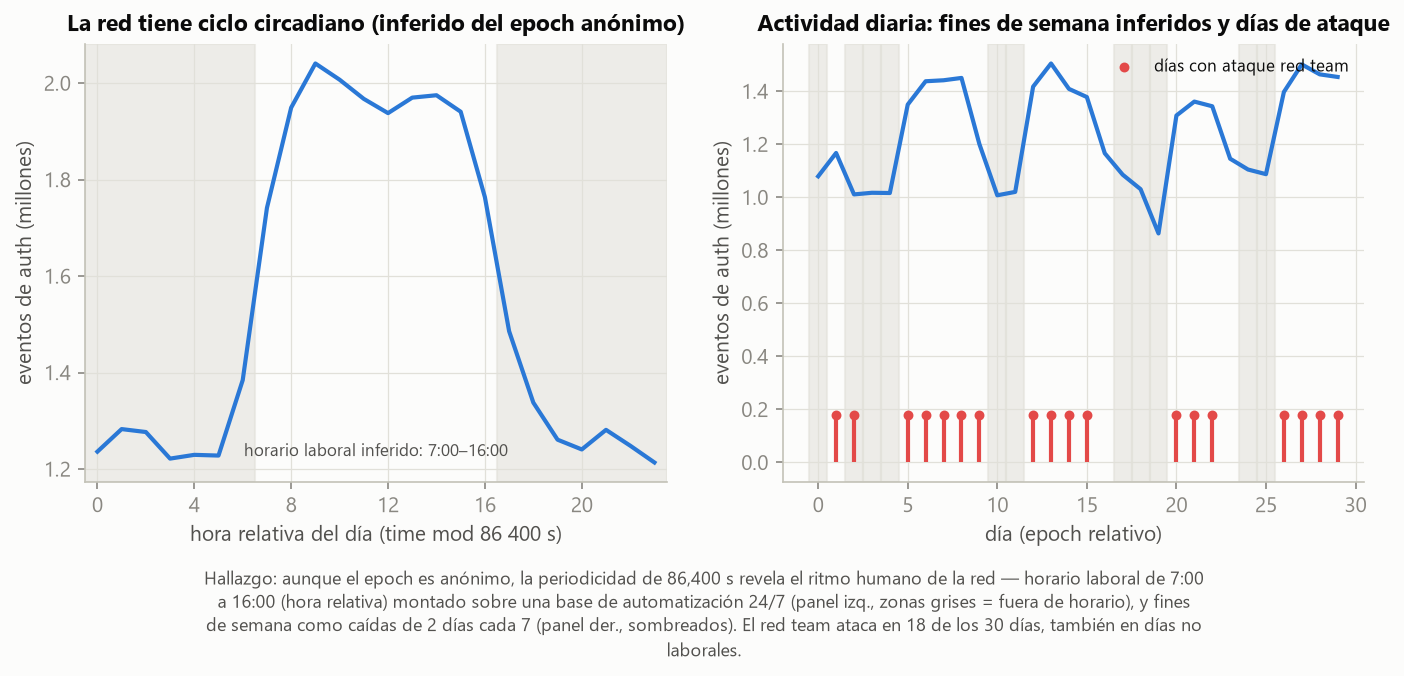

In [8]:
from IPython.display import Image, display

display(Image('../docs/eda/fig1_ritmo_red.png'))

**Interpretación de la Figura 1.** Los tres hallazgos, con los umbrales documentados en
`src/eda.py::infer_circadian`:

1. **La red tiene un horario laboral de 7:00–16:00 en hora relativa** (panel izquierdo: la meseta
   de ~2 M de eventos/hora contra el valle nocturno de ~1.2 M). El matiz metodológico importante:
   existe una base de automatización 24/7 que corre bajo cuentas de usuario — el valle conserva
   ~59% del pico — así que el umbral de "hora laboral" es el punto medio entre valle y pico; un
   porcentaje del pico habría marcado el día entero como laboral.
2. **Los fines de semana se ven sin calendario** (panel derecho): caídas de dos días con
   periodicidad exacta de 7 (días 3-4, 10-11, 17-18, 24-25), más un día 19 anómalamente bajo
   (probable feriado). Once días quedan clasificados como no laborales.
3. **El red team ataca en 18 de los 30 días, incluidos días no laborales** — el ground truth cubre
   buena parte de la ventana, lo que después permitirá que la partición temporal (sección 4.7)
   deje ataques a ambos lados del corte train/test.

### Figura 2 — ¿En qué se nota un día comprometido?

**Justificación y objetivo:** la pregunta que esta figura responde: comparando los 181 usuario-días comprometidos contra los 47,775
normales, ¿qué comportamientos los separan? Esta figura decide, con evidencia, qué señales merecen
convertirse en features en la Fase 3.

**Cómo leerla:** tres paneles, uno por señal candidata; azul = normal, rojo = comprometido en todo
el proyecto. Los paneles 1 y 3 son boxplots sin outliers (la mediana es la línea negra; si las
cajas se separan, la señal discrimina). El panel 1 usa escala logarítmica porque el alcance varía
en órdenes de magnitud. El panel central es distinto a propósito: muestra el **porcentaje de días
con al menos un fallo**, porque las distribuciones del ratio de fallos colapsan en cero y
esconderían el patrón real.

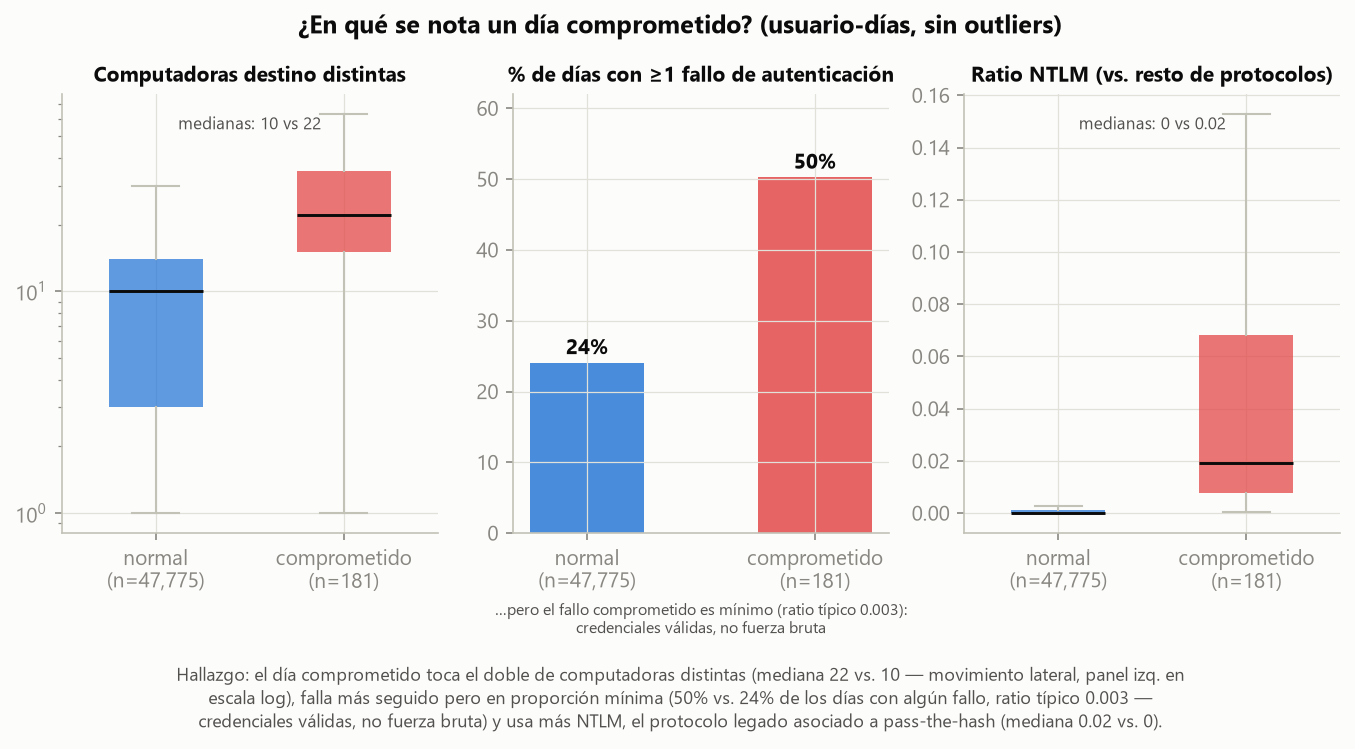

In [9]:
display(Image('../docs/eda/fig2_senales_compromiso.png'))

**Interpretación de la Figura 2**, panel por panel:

1. **Computadoras destino distintas — LA señal de movimiento lateral:** mediana de **22 destinos
   en días comprometidos vs. 10 en normales**, con los rangos intercuartílicos casi separados
   (15–35 vs. 3–14). Es la confirmación empírica de la señal más citada en la literatura sobre
   este dataset y la justificación directa del nivel completo de features de grafo (sección 4.5).
2. **Fallos de autenticación — el hallazgo contraintuitivo:** el compromiso NO se parece a fuerza
   bruta. Los días comprometidos tienen fallos *más frecuentes* (50% de los días vs. 24%) pero
   *mínimos en proporción* (ratio típico 0.003): quien usa credenciales robadas válidas avanza con
   éxito y solo ocasionalmente toca una puerta que no abre. El fallo masivo pertenece a la
   población normal — el 17% de los user-días normales son 100% fallos, la firma de automatización
   con credenciales caducas. Consecuencia para la Fase 3: una feature de fallos cruda engañaría al
   modelo; necesita el contexto de desviación personal (sección 4.3). Y refuerza la tesis del
   proyecto: el atacante moderno no rompe, entra.
3. **Ratio NTLM:** mediana 0.02 en comprometidos vs. 0 en normales — el protocolo legado asociado
   a técnicas pass-the-hash aparece desproporcionadamente en la actividad de ataque, confirmando
   su valor como feature (sección 4.2).

### Figura 3 — El movimiento lateral hecho visible: grafo ego de U3635

**Justificación y objetivo:** la pregunta que esta figura responde: ¿cómo se ve un compromiso real en el grafo de conexiones de una sola
cuenta? Es la historia visual del proyecto y el prototipo del mini-grafo de la vista de
investigación de la UI (sección 8.2 del plan).

**Cómo leerla:** el nodo azul central es el usuario U3635; cada nodo periférico es una computadora
a la que se autenticó. El panel izquierdo es su huella histórica (días 0–7); el derecho, el día del
ataque (día 8). Gris = destino que ya conocía; **rojo = destino que jamás había tocado**. Si el
compromiso implica movimiento lateral, el panel derecho debe verse notablemente más poblado que el
izquierdo y dominado por nodos rojos.

El usuario no se eligió a mano: el criterio está documentado en `src/eda.py::pick_ego_user` —
entre las 104 cuentas comprometidas, la que maximiza los destinos nuevos el día del ataque teniendo
historial previo suficiente (≥5 días) y una huella histórica legible (≤60 destinos).

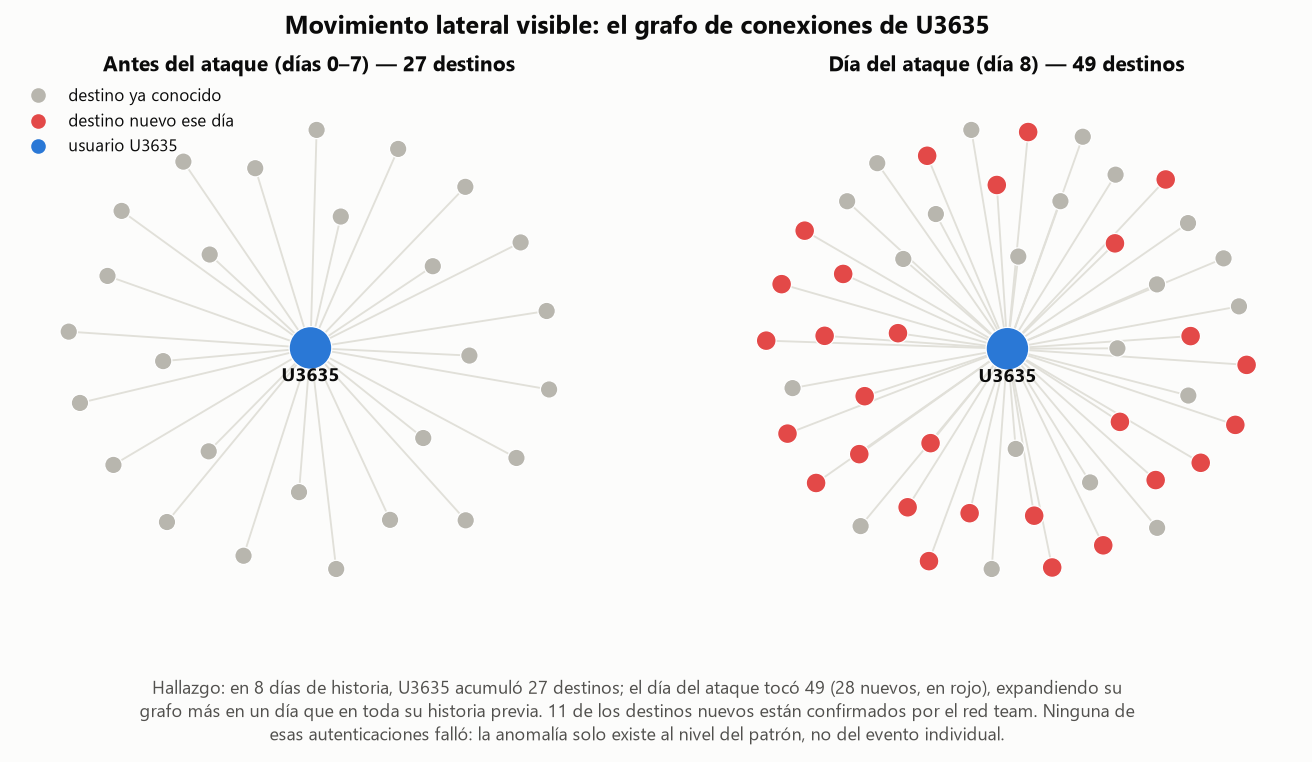

In [10]:
display(Image('../docs/eda/fig3_grafo_ego.png'))

**Interpretación de la Figura 3.** En 8 días de historia, U3635 acumuló 27 destinos. El día
del ataque tocó **49 destinos, 28 de ellos nuevos**: su grafo de conexiones se expandió más en un
solo día que en toda su historia previa, y 11 de esos destinos nuevos están confirmados en el
ground truth del red team (los restantes son candidatos a actividad de reconocimiento no
etiquetada o actividad legítima entremezclada — distinción que el modelo no necesita: puntúa el
día completo).

El detalle que hace valioso este caso para la tesis del proyecto: **ninguna de esas autenticaciones
falló ni disparó una alerta tradicional** — cada evento individual era "válido". La anomalía solo
existe al nivel del *patrón* (la novedad relativa a SU propia historia), que es exactamente lo que
las features de grafo de la sección 4.5 (`n_aristas_nuevas`, `ratio_aristas_nuevas`,
`rareza_media_de_destinos`) van a capturar de forma sistemática para los 47,956 usuario-días.

### KPIs del EDA (sección 3.3 del plan)

**Justificación y objetivo:** los KPIs son el resumen ejecutivo cuantitativo de la fase — la tabla
que permite citar el EDA sin releerlo. Su objetivo específico es dejar en un solo lugar los números
que gobiernan las decisiones de la Fase 3 (qué features construir y con qué fronteras) y que después
reaparecerán en el documento y la presentación.

**Qué buscar:** los pares normal vs. comprometido (medianas y medias) y las dos fronteras
temporales inferidas (horario laboral y días no laborales).

In [11]:
pd.Series(res['kpis'], name='valor').to_frame()

,valor
mediana n_dst (normal),10.0
mediana n_dst (comprometido),22.0
media ratio_fallos (normal),0.1765
media ratio_fallos (comprometido),0.0112
media ratio_ntlm (normal),0.0264
media ratio_ntlm (comprometido),0.104
horario laboral inferido,7:00-16:00 (hora relativa)
días no laborales inferidos,"[0, 2, 3, 4, 10, 11, 17, 18, 19, 24, 25]"
cobertura temporal de ataques,18/30 días


**Interpretación de los KPIs y conclusiones de la fase:**

- **Alcance (mediana n_dst 22 vs. 10):** el día comprometido duplica el alcance típico — la señal
  existe y es fuerte; las features de grafo (4.5) la explotarán a fondo.
- **Fallos invertidos (media 0.18 normal vs. 0.01 comprometido):** la media de fallos es *mayor*
  en la población normal por los días de automatización rota. Consecuencia directa de diseño: una
  feature de fallos cruda engañaría al modelo; solo es útil contextualizada contra el historial
  del propio usuario (desviación personal, sección 4.3).
- **NTLM (media 0.10 comprometido vs. 0.03 normal):** confirma la señal de protocolo a nivel KPI.
- **Fronteras temporales:** horario laboral 7:00–16:00 y días no laborales
  `[0, 2, 3, 4, 10, 11, 17, 18, 19, 24, 25]` — insumo directo de `n_eventos_fuera_de_horario` y
  `n_eventos_en_dia_no_laboral`.
- **Cobertura de ataques 18/30 días:** garantiza que la partición temporal estricta (4.7) dejará
  días de ataque tanto en entrenamiento como en prueba.
- **Calidad (60.2% de auth_type nulo):** el reto de campo queda cuantificado y convertido en
  feature, no barrido bajo la alfombra.

Con el comportamiento normal caracterizado, el desbalance cuantificado y las señales verificadas
empíricamente, la Fase 3 (ingeniería de variables) arranca con hoja de ruta respaldada por datos,
no por intuición.

## 3. Ingeniería de variables (Fase 3 ⭐ — la sección crítica del proyecto)

**Principio rector: el modelo no ve logs, ve desviaciones.** Un evento de autenticación aislado no
dice nada — el incidente de Nexus Sentinel ocurrió precisamente porque cada autenticación individual
era "válida". La ingeniería de variables convierte 37.6 M de eventos en 47,956 filas usuario-día
donde cada columna responde una pregunta de desviación. Son **cuatro niveles**, y cada uno existe
porque el anterior tiene un punto ciego que el atacante puede explotar:

| Nivel | Pregunta | Qué resuelve que el nivel anterior no puede |
|---|---|---|
| (a) Crudas | ¿Qué hizo hoy? | Convierte el log en la unidad de decisión del SOC; sin esto no hay nada que comparar |
| (b) Desviación personal | ¿Qué tan distinto de SU pasado? | 22 destinos son rutina para un admin y alarma para un contador: lo "normal" es personal |
| (c) Desviación grupal (peers) | ¿Qué tan distinto de SUS PARES hoy? | Usuarios con poco historial y eventos globales (un patch day dispara a TODOS: contra los pares no destaca) |
| (d) Novedad de grafo | ¿Qué tan nuevo es su grafo de conexiones? | El atacante disciplinado mantiene volumen y horario normales, pero NO puede evitar tocar máquinas que la cuenta jamás tocó |

**Reglas anti-fuga globales de la fase** (auditadas al final con la skill del proyecto
`/revisar-fugas`): toda estadística histórica excluye el día evaluado (`shift(1)`); el grafo de
referencia se congela al día D−1; el KMeans de pares se ajusta solo con días de entrenamiento;
ninguna feature deriva de `redteam.txt`; la partición es temporal estricta, nunca aleatoria.

### Ejecución del pipeline de features

**Justificación y objetivo:** el pipeline completo vive en `src/features.py` y `src/graph.py`
(código de producción, reutilizado tal cual por la API en fases posteriores); el notebook lo
ejecuta y luego **audita cada nivel por separado** en las celdas siguientes. El orden interno es:
crudas → desviación personal → grafo → peer groups → etiquetado → partición, y persiste tres
artefactos: `user_day_features.parquet` (la tabla maestra), `features_metadata.json` (trazabilidad)
y `models/peer_kmeans.joblib` (el modelo de pares, que la rúbrica reconoce como modelo no
supervisado secundario).

**Qué buscar en la salida:** dimensiones de la tabla (47,956 × 61 features) y la confirmación de
que no hay valores faltantes ni infinitos — una tabla con NaN silenciosos envenenaría el modelado.

In [12]:
import numpy as np

from src import features

ud, info = features.build_master_table(work_dir='../data/work',
                                       eda_results='../docs/eda/eda_results.json',
                                       models_dir='../models')
X = ud[info['feature_cols']].select_dtypes('number')
print(f"tabla maestra: {info['n_user_days']:,} usuario-días × {info['n_features']} features")
print(f"NaN: {int(X.isna().sum().sum())} | inf: {int(np.isinf(X.to_numpy(dtype=float)).sum())}")

tabla maestra: 47,956 usuario-días × 61 features
NaN: 0 | inf: 0


**Interpretación de la salida.** La tabla maestra queda con **47,956 usuario-días × 61
features**, sin un solo NaN ni infinito: las imputaciones documentadas (desviaciones a 0 cuando el
historial es menor a 7 días, cluster −1 para usuarios sin perfil) cierran todos los huecos de forma
explícita, no accidental. Las celdas siguientes auditan nivel por nivel qué contiene la tabla y
por qué.

### Nivel (a) — Features crudas: qué hizo hoy (sección 4.2 del plan)

**Justificación y objetivo:** cada familia de features crudas existe porque captura una táctica
concreta del uso indebido de credenciales — no son columnas "por si acaso":

- **Volumen** (`n_eventos`, `n_logons`, `n_eventos_hora_pico`): actividad automatizada bajo una
  cuenta humana (scripts de recolección, exfiltración).
- **Alcance** (`n_dst_computers`, `n_src_computers`, `ratio_dst_por_evento`): la huella del
  movimiento lateral que el EDA confirmó (mediana 22 vs. 10).
- **Fallos** (`n_fallos`, `ratio_fallos`, `n_fallos_consecutivos_max`): las ráfagas consecutivas
  delatan fuerza bruta / password spray. El EDA ya advirtió que el fallo crudo engaña (la
  automatización rota falla más que el atacante): por eso esta familia SOLO es útil combinada con
  el nivel (b).
- **Protocolo** (`n_ntlm`, `ratio_ntlm`, `n_tgt`, `n_tgs`, `ratio_tgs_por_tgt`,
  `n_auth_type_nulo`): NTLM es el vehículo clásico de pass-the-hash; el desbalance TGS/TGT delata
  abuso de tickets Kerberos; y el nulo se cuenta como información (60% del dataset).
- **Tipo de logon** (`n_interactive`, `n_remote_interactive`, `n_batch_service`): en una red donde
  Interactive es 0.2%, una sesión interactiva o RDP inusual es una señal cualitativa.
- **Temporales** (`n_fuera_horario`, `es_dia_no_laboral`, `amplitud_horaria`): usan las fronteras
  7:00–16:00 y los 11 días no laborales INFERIDOS en el EDA — actividad cuando el dueño legítimo
  probablemente no está.
- **Dirección** (`n_uso_como_identidad_destino`): cuántas veces la cuenta aparece como identidad
  DESTINO de otra identidad origen — la firma de una credencial inyectada en cadenas de saltos
  máquina-a-máquina.

**Qué buscar en la salida:** el resumen estadístico de las familias — colas pesadas (medias muy
por encima de las medianas), que es exactamente el motivo de que las crudas no basten solas.

In [13]:
crudas = ['n_eventos', 'n_dst_computers', 'n_fallos', 'n_fallos_consecutivos_max',
          'ratio_ntlm', 'n_tgs', 'n_fuera_horario', 'amplitud_horaria',
          'n_uso_como_identidad_destino']
ud[crudas].describe().T.round(2)[['mean', '50%', 'max']].rename(
    columns={'mean': 'media', '50%': 'mediana', 'max': 'máximo'})

,media,mediana,máximo
n_eventos,773.62,287.0,243541.0
n_dst_computers,10.07,10.0,2343.0
n_fallos,4.70,0.0,11434.0
n_fallos_consecutivos_max,3.96,0.0,10405.0
ratio_ntlm,0.03,0.0,1.0
n_tgs,91.10,42.0,28221.0
n_fuera_horario,372.51,86.0,112286.0
amplitud_horaria,13.38,15.0,23.0
n_uso_como_identidad_destino,10.12,0.0,17229.0


**Interpretación de la salida.** Las colas pesadas son extremas en todas las familias: la
media de `n_eventos` está muy por encima de su mediana y los máximos alcanzan órdenes de magnitud
sobre el usuario típico. Esto confirma el punto ciego del nivel (a): con distribuciones así, un
umbral global sobre cualquier feature cruda ahogaría al SOC en falsos positivos de cuentas
naturalmente ruidosas y dejaría pasar a atacantes discretos dentro de cuentas silenciosas. La
solución no es otro umbral: es cambiar la pregunta — comparar a cada usuario contra sí mismo.

### Nivel (b) — Desviación personal: contra su propio pasado (sección 4.3, corazón del proyecto)

**Justificación y objetivo:** este nivel resuelve el problema que mató la detección en el caso
Nexus Sentinel: lo "normal" es personal. Para cada una de las 11 features clave se calculan, sobre
una ventana móvil de hasta 30 días activos previos del usuario:

- **`z_*` (z-score):** a cuántas desviaciones estándar está el día de la media histórica del
  propio usuario — la magnitud de la anomalía en unidades comparables entre usuarios.
- **`ratio_max_*`:** el día contra el MÁXIMO histórico — detecta récords personales aunque la
  varianza histórica sea alta (un z modesto puede ocultar un "nunca había hecho tanto").
- **`primera_vez_*`:** flags de eventos cualitativos (primer NTLM, primer fuera de horario,
  primer fallo) — hay comportamientos donde el salto de 0 a 1 vale más que cualquier magnitud.

**La regla anti-fuga central de la fase:** todas las estadísticas se calculan con `shift(1)` — la
serie del usuario desplazada un día activo — de modo que el día evaluado JAMÁS participa en su
propia línea base. Sin esto, un día de ataque masivo elevaría su propia media y se auto-camuflaría.
Complemento (sección 4.7): con historial menor a 7 días la línea base no es confiable, así que las
desviaciones se imputan a 0 y se enciende `historial_corto` — el modelo aprende explícitamente a
desconfiar de desviaciones sin historia.

**Qué buscar en la salida:** el día del ataque de U3635 (el mismo de la Figura 3) traducido a
features. La pregunta clave: ¿el volumen lo delata, o la novedad?

In [14]:
caso = ud[(ud.src_user == 'U3635@DOM1') & (ud.day == 8)][
    ['n_eventos', 'z_n_eventos', 'n_dst_computers', 'z_n_dst_computers',
     'ratio_max_n_dst_computers', 'z_peer_n_dst_computers', 'n_aristas_nuevas',
     'ratio_aristas_nuevas', 'rareza_media_destinos', 'historial_dias', 'y']].T
caso.columns = ['U3635 — día 8 (día del ataque)']
caso.round(3)

,U3635 — día 8 (día del ataque)
n_eventos,761.000
z_n_eventos,0.687
n_dst_computers,49.000
z_n_dst_computers,7.694
ratio_max_n_dst_computers,1.885
z_peer_n_dst_computers,4.548
n_aristas_nuevas,28.000
ratio_aristas_nuevas,0.571
rareza_media_destinos,0.378
historial_dias,8.000


**Interpretación de la salida — la tesis del proyecto en una fila.** El día del ataque,
el VOLUMEN de U3635 parece normal: `z_n_eventos` = **0.69** (menos de una desviación estándar de
su propia media — un detector de volumen no lo vería). Pero las desviaciones de alcance y novedad
lo delatan por completo: tocó destinos a **7.7σ** de su línea base personal (`z_n_dst_computers`),
rompió su máximo histórico por 88% (`ratio_max` = 1.88), quedó a **4.5σ** de sus pares
conductuales ese mismo día, y 28 de sus 49 destinos eran nuevos (`ratio_aristas_nuevas` = 0.57)
con una rareza media 8 veces superior a la mediana normal. Esta fila es la narrativa que el plan
exige habilitar — *"hoy tocó 49 servidores; su historia decía otra cosa"* — y anticipa la
explicación SHAP que el analista verá en la UI.

### Nivel (c) — Peer groups conductuales: contra sus pares (sección 4.4)

**Justificación y objetivo:** la desviación personal tiene dos puntos ciegos: usuarios con poco
historial (nada contra qué compararse) y eventos globales legítimos — un patch day o una migración
disparan la actividad de TODOS, y castigar a cada usuario por su z personal generaría una ola de
falsos positivos. La comparación contra pares resuelve ambos: si todos los de tu rol subieron hoy,
tú no destacas. Como los datos están desidentificados (sin LDAP, sin departamentos), los "pares"
se construyen **conductualmente**: KMeans sobre el perfil mediano de cada usuario en el periodo de
entrenamiento, con k elegido por silhouette. Esto aporta además el modelo no supervisado
secundario que exige la rúbrica.

**Rectificación metodológica documentada:** la primera corrida produjo un clustering degenerado —
k=2 con un cluster de **1 solo usuario** y silhouette engañosamente alto (0.997): una cuenta
outlier secuestraba el clustering, y un cluster unipersonal no es un peer group (no hay nadie
contra quién compararse). Se corrigió con dos salvaguardas: `log1p` sobre las features de volumen
antes del escalado robusto, y la regla de que un k solo es candidato si su cluster más chico
agrupa ≥1% de los usuarios. Se documenta porque ES el tipo de decisión que separa un clustering
decorativo de uno útil.

**Qué buscar en la salida:** la tabla de silhouette por k (todas las soluciones ahora válidas) y
el perfil mediano de cada cluster — ¿los roles se pueden nombrar?

In [15]:
import pandas as pd

sil = pd.DataFrame(info['silhouette_por_k']).T
sil.index.name = 'k'
display(sil.round(3))
roles = ud[ud.day < info['constantes']['SPLIT_DAY']].groupby('peer_cluster')[
    features.PEER_PROFILE_COLS].median().round(2)
roles['n_usuarios'] = ud.groupby('peer_cluster')['src_user'].nunique()
roles

,silhouette,min_cluster,valido
k,,,
2,0.630153,1375,True
3,0.566634,979,True
4,0.543977,454,True
5,0.552671,419,True
6,0.576306,113,True
7,0.548799,113,True
8,0.518612,113,True
9,0.534595,56,True
10,0.536769,47,True


,n_eventos,n_dst_computers,n_src_computers,ratio_ntlm,ratio_fallos,n_fuera_horario,amplitud_horaria,n_usuarios
peer_cluster,,,,,,,,
0,6.0,2.0,2.0,0.0,1.0,0.0,0.0,2332
1,406.0,12.0,9.0,0.0,0.0,175.0,23.0,1375


**Interpretación de la salida.** El silhouette elige **k=2** (0.63, con clusters de 1,375 y
2,332 usuarios — ya sin degeneración), y los dos roles conductuales se nombran solos:

- **Cluster 0 — "cuentas ligeras e intermitentes"** (2,332 usuarios): mediana de 6 eventos y 2
  destinos por día, sin actividad fuera de horario. Aquí vive también el fenómeno de los días de
  puro fallo (mediana de `ratio_fallos` = 1.0): la automatización rota que el EDA identificó.
- **Cluster 1 — "cuentas pesadas siempre encendidas"** (1,375 usuarios): mediana de 406 eventos,
  12 destinos, 175 eventos fuera de horario y amplitud de 23 horas — usuarios intensivos y
  automatización corriendo bajo cuentas de usuario.
- **Cluster −1** (397 usuarios): sin días en el periodo de entrenamiento; su desviación grupal se
  imputa a 0 con el flag `sin_peer_group`.

Que los clusters separen precisamente los dos regímenes que contaminaban las features crudas
(cuentas ruidosas vs. silenciosas) es lo que hace útil la desviación grupal: la mediana de
`z_peer_n_dst_computers` en días comprometidos es 0.66 vs. −0.16 en normales — el ataque destaca
incluso contra el rol correcto.

### Nivel (d) — Novedad de grafo: contra su historia de conexiones (sección 4.5, nuevas en v2)

**Justificación y objetivo:** el punto ciego que queda es el atacante disciplinado — volumen
normal, horario laboral, sin fallos, protocolo limpio. Lo único que NO puede evitar es tocar
máquinas que la cuenta jamás tocó: el movimiento lateral es, por definición, novedad de
conexiones. Sobre un grafo bipartito acumulado usuario→computadora se calculan:

- **`n_aristas_nuevas` / `ratio_aristas_nuevas`:** destinos jamás tocados por el usuario, en
  absoluto y como fracción del día (separa "un servidor nuevo" — rutina — de "casi todo lo de hoy
  es nuevo" — expansión).
- **`rareza_media_destinos`:** pondera CADA destino por 1/(1+usuarios que lo habían tocado):
  tocar el file server común no es como tocar un servidor que casi nadie visita.
- **`n_src_computers_nuevas`:** máquinas ORIGEN nuevas — la credencial viajando a equipos donde
  nunca vivió.

**Regla anti-fuga estricta:** el grafo de referencia del día D se congela al final del día D−1 —
la implementación calcula las features del día ANTES de incorporar sus eventos al estado. El
primer día activo de cada usuario se neutraliza a 0 (todo sería "nuevo" por construcción, no por
conducta).

**Qué buscar en la salida:** medianas por clase — si el nivel funciona, los días comprometidos
deben mostrar novedad y rareza claramente superiores.

In [16]:
grafo_cols = ['n_aristas_nuevas', 'ratio_aristas_nuevas', 'rareza_media_destinos',
              'n_src_computers_nuevas', 'n_uso_como_identidad_destino']
tabla_grafo = ud.groupby('y')[grafo_cols].median().T.round(3)
tabla_grafo.columns = ['normal (mediana)', 'comprometido (mediana)']
tabla_grafo

,normal (mediana),comprometido (mediana)
n_aristas_nuevas,0.000,1.000
ratio_aristas_nuevas,0.000,0.068
rareza_media_destinos,0.044,0.133
n_src_computers_nuevas,0.000,2.000
n_uso_como_identidad_destino,0.000,20.000


**Interpretación de la salida.** Las cuatro features de grafo separan las clases en mediana:
el usuario-día normal NO abre aristas nuevas (mediana 0 — la rutina es rutina), mientras el día
comprometido abre 1+ aristas, se autentica desde 2 máquinas origen nuevas y triplica la rareza
media de sus destinos (0.133 vs. 0.044). La sorpresa es `n_uso_como_identidad_destino`: mediana
**20 vs. 0** — durante el ataque, la credencial aparece como identidad destino de otras identidades
veinte veces por día (la firma de las cadenas de salto del red team), cuando lo normal es cero.
Estas features, más las desviaciones del nivel (b), son las candidatas a dominar el SHAP del
modelo en la Fase 4.

### Etiquetado con el ground truth real (sección 4.6)

**Justificación y objetivo:** las etiquetas convierten el problema en aprendizaje supervisado:
`y=1` si el usuario-día contiene ≥1 evento del red team. Se guarda también `n_eventos_redteam`
para análisis de severidad — pero **fuera de la lista de features**: ninguna columna derivada de
`redteam.txt` puede entrar al modelo (sería entrenar con la respuesta). El objetivo específico de
esta celda es verificar la **cobertura**: que cada par (usuario, día) del red team tenga su fila
en la tabla maestra — un par perdido sería un ataque invisible para el entrenamiento.

**Qué buscar en la salida:** `pares_sin_fila_usuario_dia` debe ser 0.

In [17]:
print(info['cobertura_etiquetas'])
print(f"desbalance de la tabla maestra: {ud.y.sum()} de {len(ud):,} "
      f"({ud.y.mean()*100:.2f}%) usuario-días maliciosos")

{'pares_redteam_distintos': 181, 'pares_capturados_en_tabla': 181, 'pares_sin_fila_usuario_dia': 0}
desbalance de la tabla maestra: 181 de 47,956 (0.38%) usuario-días maliciosos


**Interpretación de la salida.** Cobertura perfecta: los **181 pares (usuario, día)** del
red team tienen su fila en la tabla maestra — cero ataques invisibles. El desbalance queda en
0.38% (1 de cada 265), consistente con el EDA; este número gobierna el `scale_pos_weight` del
XGBoost y las métricas de la Fase 4.

### Verificación de integridad del ground truth a nivel evento

**Justificación y objetivo:** la cobertura anterior verificó las etiquetas al grano del modelo
(usuario-día); esta celda baja un nivel más y audita el ground truth **evento por evento**: LANL
declara que `redteam.txt` es un subconjunto de `auth.txt`, así que cada línea red team debería
tener su evento de autenticación exacto (mismo `time`, usuario, computadora origen y destino) en
nuestra muestra. Una discrepancia grande indicaría un problema de muestreo o de alineación de
tiempos que invalidaría las etiquetas; una discrepancia pequeña y explicable es una nota de
calidad que debe quedar documentada, no escondida.

**Qué buscar en la salida:** cuántos de los 715 eventos red team encuentran su línea exacta en
auth, y el desglose de resultado (Success/Fail) de los que sí.

In [18]:
import polars as pl

auth_pl = pl.scan_parquet('../data/work/auth_sample.parquet')
rt_pl = pl.from_pandas(redteam[['time', 'user', 'src_computer', 'dst_computer']])
match = (auth_pl.select('time', 'src_user', 'src_computer', 'dst_computer', 'outcome').collect()
         .join(rt_pl, left_on=['time', 'src_user', 'src_computer', 'dst_computer'],
               right_on=['time', 'user', 'src_computer', 'dst_computer'], how='inner'))
print(f"eventos red team: {len(redteam)} | con línea auth exacta en la muestra: {match.select(pl.len()).item()}")
print(match.group_by('outcome').len().sort('outcome').to_pandas().to_string(index=False))

eventos red team: 715 | con línea auth exacta en la muestra: 702
outcome  len
   Fail    1
Success  701


**Interpretación de la salida.** **702 de los 715 eventos red team (98.2%) tienen su línea
de autenticación exacta en la muestra.** Los 13 restantes son una imperfección conocida del ground
truth de LANL: se concentran en el día 8 (más dos en el día 12), todos con origen en C17693 — la
computadora principal del ataque — y para algunos no existe ningún evento auth del usuario a ese
destino en todo el día (no es un problema de nuestra ventana ni del muestreo: la línea no está en
`auth.txt`). Lo crucial es que **las etiquetas no se ven afectadas**: los 13 eventos pertenecen a
pares (usuario, día) donde el usuario sí tuvo otra actividad, así que los 181 pares siguen
etiquetados — verificado en la celda de cobertura anterior.

El desglose de resultados deja además un dato valioso para el documento: de los 702 eventos
matcheados, **701 fueron Success y solo 1 Fail** — el red team autenticó con éxito el 99.9% de las
veces. Es la confirmación definitiva, ahora a nivel evento, de la tesis del proyecto: el atacante
con credenciales robadas no rompe puertas, las abre.

### Partición temporal estricta (sección 4.7)

**Justificación y objetivo:** la partición decide si la evaluación será creíble. Un k-fold
aleatorio está prohibido aquí por dos razones: (1) los días de un mismo usuario están
autocorrelacionados — el modelo "reconocería" usuarios en lugar de generalizar comportamiento —
y (2) las features históricas de un día de test construido con días de train mezclados filtrarían
información del futuro. La partición es por día calendario: **train = días 0–19, test = días
20–29** (67/33), simulando el despliegue real: entrenar con el pasado, puntuar el futuro.

**Qué buscar en la salida:** que ambos lados contengan días de ataque (sin ataques en test no
habría nada que evaluar) y que el desbalance sea comparable.

In [19]:
split_tabla = pd.DataFrame(info['split']).T[['user_days', 'maliciosos', 'dias_ataque']]
split_tabla

,user_days,maliciosos,dias_ataque
split_day,20,20,20
train,30455,147,"[1, 2, 5, 6, 7, 8, 9, 12, 13, 14, 15]"
test,17501,34,"[20, 21, 22, 26, 27, 28, 29]"


**Interpretación de la salida.** El corte en el día 20 deja **147 usuario-días maliciosos
en train** (días de ataque 1–15) y **34 en test** (días 20–29): ambos lados tienen señal, con
desbalances comparables (0.48% y 0.19%). El modelo se entrenará con campañas de ataque que ocurrieron
ANTES del corte y se evaluará sobre campañas posteriores que jamás vio — exactamente el escenario
de producción de un SOC.

**Cierre de la fase.** La tabla maestra queda lista para el modelado: 47,956 usuario-días × 61
features en cuatro niveles justificados, sin fugas (auditoría `/revisar-fugas` en el repositorio),
sin NaN, con etiquetas completas y partición temporal verificada. Queda abierta la iteración
obligatoria de la sección 4.8: tras el primer modelo y su SHAP global, se volverá a esta sección
para registrar qué features se agregan o eliminan y por qué.

## 4. Modelado (Fase 4)

Enfoque híbrido de la sección 5 del plan: un **baseline no supervisado** (Isolation Forest + el
score de anomalía del KMeans de pares), un **modelo supervisado central** (XGBoost, con Random
Forest y Regresión Logística como referencias), **calibración de probabilidades** y una evaluación
cerrada con **reporte de estabilidad OOT** (PSI, CSI, KS con tabla de deciles TE/TNE).

**Los tres conjuntos (decisión tomada con datos, no por convención):** la partición train/test de
la Fase 3 se refina en train (días 0–13), **validación (días 14–19)** y test/OOT (días 20–29).
El corte de validación no fue arbitrario: cortar en el día 16 habría dejado la validación con
**cero positivos** (no hay ataques en los días 16–19), y cortar en 15 la dejaba con 14. El corte
en 14 deja 27 positivos para validar — el mínimo razonable para early stopping, selección de
modelo, calibración y umbrales. Todo lo que requiere decidir (hiperparámetros, calibrador, modelo
ganador, umbrales SOC) se decide en validación; **el test se toca una sola vez, al final**.

La celda siguiente ejecuta la fase completa (`src/models.py::run_fase4`, ~5–10 min): baseline no
supervisado, búsqueda de hiperparámetros con early stopping, iteración 4.8, referencias,
selección, calibración, evaluación en test, estabilidad y SHAP.

In [20]:
from src import models

rep = models.run_fase4(work_dir='../data/work', models_dir='../models',
                       out_dir='../docs/modeling')
pd.DataFrame(rep['conjuntos']).T

D:\Ciencia de Datos\nexus-sentinel\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,user_days,positivos,dias
train,22308,120,"[0, 13]"
val,8147,27,"[14, 19]"
test,17501,34,"[20, 29]"


**Interpretación de la salida.** Los tres conjuntos quedan con 22,308 / 8,147 / 17,501
usuario-días y **120 / 27 / 34 positivos** respectivamente — cronológicamente disjuntos y todos
con señal. El test es genuinamente *out-of-time*: contiene las campañas de ataque de los días
20–29, que ningún paso de entrenamiento, tuning ni calibración vio jamás.

### 4.1 No supervisado — Isolation Forest (baseline)

**Justificación de cada decisión (los cuatro puntos de diseño):**

1. **`contamination='auto'`.** Fijarlo con la tasa real de ataque (0.38%) sería filtrar
   información de las etiquetas a un modelo que se presume sin etiquetas — la tasa se conoce
   PORQUE existe redteam.txt. Además el parámetro solo desplaza el corte binario interno; el
   *ranking* de anomalía (que es lo que evaluamos y lo que consume la puntuación híbrida) no
   cambia, y el umbral operativo real lo pone la capacidad del SOC, no el modelo.
2. **Entrenamiento sin etiquetas y solo con train.** `fit(X_train)` — sin `y` en ninguna parte, y
   solo días 0–13: aunque el modelo no vea etiquetas, dejarle ver los días de test contaminaría
   la evaluación OOT (aprendería la distribución del futuro).
3. **Evaluación a posteriori.** Las etiquetas se usan exclusivamente para MEDIR sus scores en
   test (PR-AUC, recall@FPR) — el orden causal es limpio: primero puntúa, después se le califica.
4. **Elección de features comparada, no supuesta.** IF sufre en alta dimensión con features de
   escala dispar, así que se comparan dos vistas: las 61 features completas vs. una vista
   compacta de 36 (solo desviaciones, novedad de grafo y flags).

**Qué buscar en la salida:** la comparación de ambas vistas contra las etiquetas de test.

In [21]:
pd.DataFrame(rep['if']).T.drop('elegido', errors='ignore')

,n_features,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
todas_las_features,61.0,0.027053,0.758833,0.117647,0.088235,0.098361,0.684636
desviaciones_y_grafo,36.0,0.005702,0.702533,0.029412,0.0,0.021442,0.510357


**Interpretación de la salida — con una sorpresa que vale la pena narrar.** La vista con
las **61 features completas gana con claridad** (PR-AUC 0.027, ROC-AUC 0.759) sobre la vista
"curada" de desviaciones (PR-AUC 0.006): la intuición de que menos dimensiones ayudarían resultó
falsa, y la explicación es instructiva — las desviaciones ya vienen recortadas (clip ±50) e
imputadas a 0 en historial corto, lo que comprime justo las colas que Isolation Forest necesita
para aislar puntos; las crudas conservan esas colas. Con todo, el baseline es débil en términos
absolutos: PR-AUC 0.027 es ~14× el azar (0.0019) pero muy lejos del supervisado — exactamente el
papel esperado para un baseline sin etiquetas: útil como piso de referencia y como componente del
score híbrido, insuficiente como detector único.

### 4.2 No supervisado — KMeans de peer groups (modelo secundario y generador de features)

**Justificación de sus tres papeles:**

1. **Construcción de los clusters:** NO se reconstruyen aquí — se reutilizan congelados de la
   Fase 3 (k=2 por silhouette con salvaguardas anti-degeneración, ajustado solo con train).
   Reajustarlos en esta fase con más días sería fuga temporal.
2. **Puntuación de anomalía desde KMeans:** la distancia del vector del DÍA (las 7 features de
   perfil, con el mismo log1p+escalado congelado) al centroide del rol del usuario. Lectura:
   "¿qué tan lejos está el día de hoy del prototipo de su rol conductual?". Se evalúa a
   posteriori igual que el IF.
3. **Uso como feature:** esa distancia (`dist_peer_centroide`) se prueba como feature del
   supervisado — y esto ES la iteración obligatoria de la sección 4.8: se agrega, se re-entrena
   y se decide con datos si se queda.

**Qué buscar en la salida:** el desempeño del score KMeans en test y el veredicto de la
iteración 4.8.

In [22]:
display(pd.Series(rep['kmeans_score'], name='score KMeans (test)').to_frame().T.round(4))
print('iteración 4.8:', rep['iteracion_4_8'])
print(f"PR-AUC val sin dist_peer_centroide: {rep['xgb_ronda1']['pr_auc_val']:.4f}")
print(f"PR-AUC val con dist_peer_centroide: {rep['xgb_ronda2_con_dist_kmeans']['pr_auc_val']:.4f}")

,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
score KMeans (test),0.0929,0.7041,0.0882,0.0882,0.1395,3.2224


iteración 4.8: {'feature_agregada': 'dist_peer_centroide', 'se_conserva': False}
PR-AUC val sin dist_peer_centroide: 0.2264
PR-AUC val con dist_peer_centroide: 0.2227


**Interpretación de la salida.** Dos resultados honestos:

- Como score de anomalía, la distancia al centroide del rol **supera al Isolation Forest**
  (PR-AUC 0.093 vs. 0.027) siendo un modelo mucho más simple — la comparación contra "gente como
  tú" es más informativa que la anomalía global, coherente con todo lo que el proyecto viene
  encontrando.
- Como feature del supervisado, la iteración 4.8 la **rechaza**: PR-AUC de validación 0.2264 sin
  ella vs. 0.2227 con ella. La información que aporta ya está capturada por las features
  `z_peer_*` de la Fase 3. Se documenta la prueba y la decisión negativa — la iteración
  obligatoria del plan está cumplida, y un "no mejoró, no se queda" respaldado por números vale
  más que acumular features por inercia.

### 4.3 Supervisado — XGBoost (modelo central)

**Justificación de cada decisión:**

1. **Manejo del desbalance:** `scale_pos_weight = 184.9` — el cociente negativos/positivos DEL
   TRAIN (22,188/120), no de toda la tabla (usar la tabla completa filtraría información de la
   distribución de val/test). Cada positivo pesa lo que ~185 negativos en el gradiente, forzando
   al modelo a no ignorar la clase minoritaria sin fabricar datos sintéticos.
2. **Validación y early stopping:** cada candidato entrena hasta 2,000 árboles pero se detiene
   cuando el `aucpr` de validación deja de mejorar por 50 rondas — el número de árboles no es un
   hiperparámetro a adivinar sino un resultado del early stopping (el ganador paró en 62).
3. **Hiperparámetros tuneados:** búsqueda aleatoria de 40 configuraciones sobre 7 hiperparámetros
   (profundidad, learning rate, min_child_weight, submuestreos, regularización L2, gamma),
   evaluadas por PR-AUC en la validación temporal — jamás k-fold aleatorio: mezclaría días del
   mismo usuario entre train y validación y las features históricas cruzarían el corte.

**Qué buscar en la salida:** la configuración ganadora y el top-5 de la búsqueda — si las mejores
configuraciones se parecen entre sí, la búsqueda convergió a una región estable y no a un golpe
de suerte.

In [23]:
print('configuración ganadora:')
display(pd.Series(rep['xgb_ronda1']['params'], name='valor').to_frame().round(4))
display(pd.read_csv('../docs/modeling/tuning_top10.csv').head(5).round(4))

configuración ganadora:


,valor
max_depth,3.0000
learning_rate,0.0987
min_child_weight,17.4707
subsample,0.7146
colsample_bytree,0.9624
reg_lambda,0.1154
gamma,0.3155
best_iteration,62.0000
pr_auc_val,0.2264


,max_depth,learning_rate,min_child_weight,subsample,colsample_bytree,reg_lambda,gamma,best_iteration,pr_auc_val
0,3,0.0987,17.4707,0.7146,0.9624,0.1154,0.3155,62,0.2264
1,3,0.0513,2.2237,0.7326,0.7603,1.2511,0.0114,231,0.2243
2,3,0.1284,1.4804,0.6495,0.9638,0.9862,0.0649,101,0.2126
3,3,0.1499,7.3048,0.7626,0.9070,0.2615,0.0115,69,0.2107
4,3,0.0529,10.4125,0.6331,0.7433,1.6857,3.4051,133,0.2086


**Interpretación de la salida.** El ganador es un modelo deliberadamente **pequeño y
regularizado**: `max_depth=3`, `learning_rate≈0.10`, `min_child_weight≈17` y solo 62 árboles.
Tiene todo el sentido con 120 positivos de entrenamiento: árboles poco profundos y hojas con
peso mínimo alto impiden memorizar los 120 casos. El top-5 de la búsqueda comparte ese patrón
(profundidades 3–4, min_child_weight alto), señal de que la región óptima es estable y no un
punto afortunado del muestreo aleatorio.

### 4.4 Selección del mejor modelo (criterios justificados)

**Justificación de los criterios:** la selección se hace EN VALIDACIÓN (el test no participa —
si se eligiera con test, el test dejaría de ser una estimación honesta). Criterio rector:
**PR-AUC**, porque con 0.33% de positivos es la métrica que mide lo que el SOC vive (precisión a
cada nivel de recall); desempate por **recall@FPR=1%** (cuántos compromisos caza el modelo al
costo de falsos positivos que el SOC tolera). Los tres candidatos compiten con sus mejores
hiperparámetros encontrados sobre la misma validación: XGBoost (búsqueda de 40 configs), Random
Forest (grid de profundidad, `class_weight='balanced_subsample'`) y Regresión Logística (grid de
C, con `QuantileTransformer` DENTRO de su pipeline — la transformación de colas que la revisión
de limpieza mandató per-modelo, ajustada solo con train).

**Qué buscar en la salida:** la tabla comparativa en validación.

In [24]:
tabla_sel = pd.DataFrame(rep['seleccion_val']).T.round(4)
tabla_sel['params'] = [rep['xgb_ronda1']['params'] if m == 'xgboost'
                       else rep['referencias'][m]['params'] for m in tabla_sel.index]
tabla_sel

,pr_auc_val,recall@fpr1%_val,params
xgboost,0.2264,0.6296,"{'max_depth': 3, 'learning_rate': 0.0986952653..."
rf,0.1075,0.3704,"{'max_depth': None, 'n_estimators': 400}"
logreg,0.0850,0.3333,"{'C': 0.01, 'transform': 'QuantileTransformer(..."


**Interpretación de la salida.** **XGBoost gana por más del doble**: PR-AUC 0.226 vs. 0.107
(RF) y 0.085 (LR), y con recall@FPR=1% de 0.63 vs. 0.37/0.33. La lectura metodológica: la ventaja
de XGBoost sobre RF con este desbalance viene del boosting con `scale_pos_weight` (cada positivo
re-pesado en el gradiente) frente al promediado de árboles; y la LR lineal, aun con colas
transformadas, no captura las interacciones (p. ej. "NTLM alto Y destinos nuevos") que definen el
patrón de ataque. XGBoost queda como modelo central, como establecía el plan — pero ahora con la
evidencia comparativa que lo justifica.

### 4.5 Calibración de probabilidades

**Justificación:** la salida cruda de un XGBoost re-pesado con `scale_pos_weight=185` NO es una
probabilidad — está inflada por diseño. Como la puntuación de riesgo 0–100 (Fase 5) y los
umbrales del SOC se construyen sobre ella, necesita ser interpretable: "0.30" debe significar
~30% de probabilidad real de compromiso. La calibración se ajusta SOLO con validación (calibrar
con train sobreajustaría a scores que el modelo ya memorizó; calibrar con test lo quemaría). El
método no se eligió por dogma: isotónica (no paramétrica, riesgo de sobreajuste con 27 positivos)
vs. Platt (paramétrica, más rígida) se compararon por **Brier score en CV de 5 folds dentro de la
validación**.

**Qué buscar en la salida:** el método ganador y qué tan cerca quedaron.

In [25]:
pd.Series(rep['calibracion']['brier_cv_val'],
          name=f"Brier CV en val (ganador: {rep['calibracion']['metodo']})").to_frame().round(5)

,Brier CV en val (ganador: isotonic)
isotonic,0.00294
platt,0.00299


**Interpretación de la salida.** La **isotónica gana por un margen mínimo** (Brier 0.00294
vs. 0.00299). Con 27 positivos la diferencia no es concluyente, pero el resultado respalda usar
la calibración isotónica que el plan estipulaba — ahora con verificación empírica en lugar de
fe. El Brier absoluto (~0.003) confirma que tras calibrar, las probabilidades están bien
alineadas con las frecuencias observadas en validación.

### 4.6 Evaluación final en test (una sola pasada, OOT)

**Justificación y objetivo:** todas las decisiones ya están tomadas; esta es la estimación
honesta de desempeño futuro. Métricas de la sección 5.4 del plan: PR-AUC (rectora), ROC-AUC
(reportada CON advertencia: con 0.19% de positivos, un ROC-AUC alto es engañosamente cómodo — el
99.8% de pares comparados son triviales), recall a FPR fijo (1% y 0.1% — el régimen real de un
SOC), F1 máximo, matriz de confusión al umbral naranja calibrado por capacidad (20 tickets/día,
fijado con la distribución de VALIDACIÓN), y la curva alertas/día vs. recall — el puente
modelo↔negocio.

**Qué buscar en la salida y la figura:** el lift sobre el azar en PR-AUC, el contraste
supervisado vs. baseline, y cuánto recall compra cada presupuesto de alertas.

,pr_auc,roc_auc,recall@fpr1.0%,recall@fpr0.1%,f1_max,umbral_f1_max
modelo_calibrado,0.0562,0.9389,0.3354,0.0973,0.1649,0.1562
isolation_forest,0.0271,0.7588,0.1176,0.0882,0.0984,0.6846


umbrales SOC (fijados en val): {'naranja': 0.0784, 'rojo': 0.1562}
confusión al umbral naranja (test): {'TP': 13, 'FP': 280, 'FN': 21, 'TN': 17187}


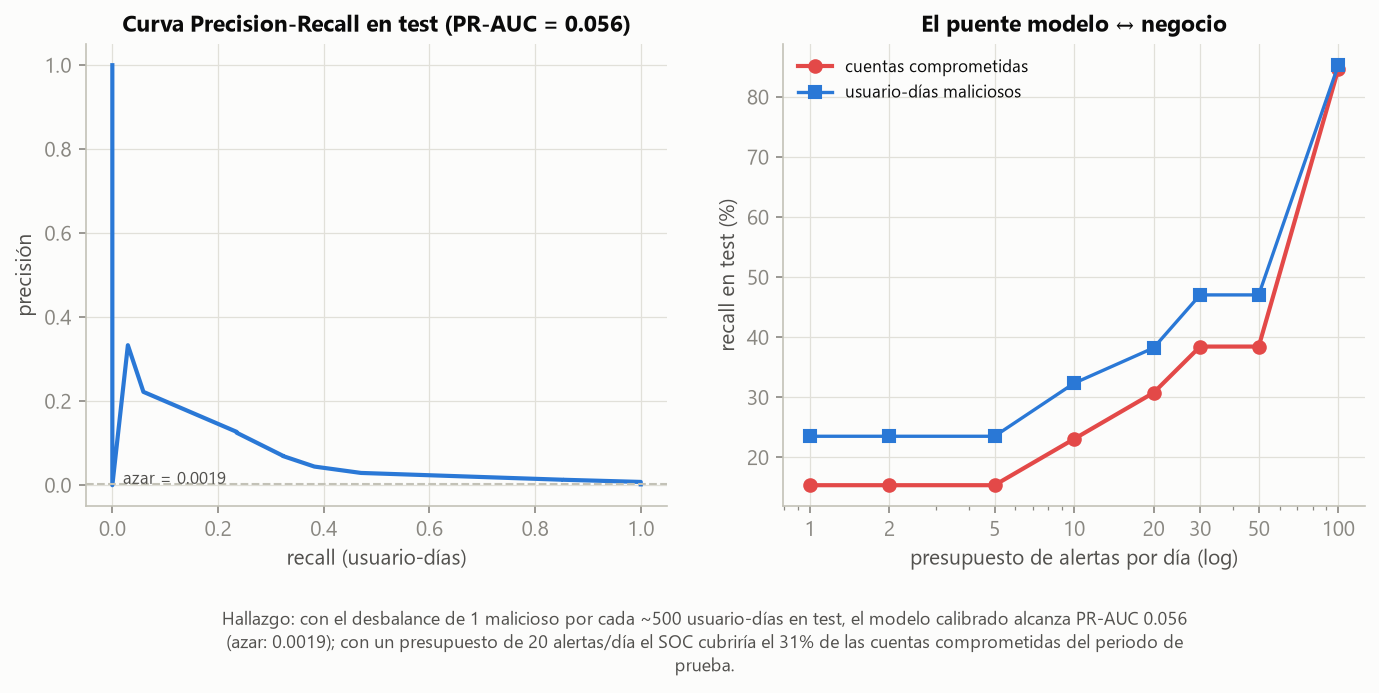

In [26]:
display(pd.DataFrame(rep['test']).T.round(4))
print('umbrales SOC (fijados en val):', {k: round(v, 4) for k, v in rep['umbrales_soc'].items()})
print('confusión al umbral naranja (test):', rep['confusion_naranja_test'])
display(Image('../docs/modeling/fig4_evaluacion.png'))

**Interpretación de la salida — resultados honestos, sin maquillaje:**

- **PR-AUC 0.056 en test = 29× el azar** (0.0019). Es una caída real frente al 0.226 de
  validación, y las causas son identificables: solo 34 positivos en OOT (intervalos anchos por
  naturaleza) y campañas de ataque distintas a las de entrenamiento — el red team no repite
  guion. Esto es lo que el despliegue real se encontraría.
- **ROC-AUC 0.939** — excelente en apariencia, y por eso el plan obliga a reportarla con
  advertencia: la curva PR de al lado cuenta la historia verdadera con este desbalance.
- **Recall@FPR=1% de 0.34**: un tercio de los usuario-días comprometidos cae dentro del 1% de
  falsos positivos. En el régimen ultra-estricto (FPR=0.1%) captura ~10%.
- **Matriz al umbral naranja** (TP=13, FP=280, FN=21, TN=17,187): ~29 alertas/día reales (el
  umbral se fijó para ~20 con la distribución de val — la deriva de score entre periodos mueve
  ligeramente el volumen, argumento para recalibrar umbrales de forma periódica en operación).
- **El puente con el negocio** (panel derecho): con 20 alertas/día se cubre el **31% de las
  cuentas comprometidas** del periodo; con 30/día el 38%; con 100/día el **85%**. Esta curva es
  LA herramienta para negociar capacidad del SOC con dirección: convierte "¿qué tan bueno es el
  modelo?" en "¿cuántos analistas cuesta cada punto de recall?".

### 4.7 Reporte de estabilidad (OOT): PSI, CSI, KS y tabla de deciles TE/TNE

**Justificación:** un modelo que discrimina pero se desestabiliza entre periodos no es
desplegable. Sobre el periodo OOT (días 20–29) se mide: **PSI** del score train→OOT (¿la
distribución de puntuaciones cambió? <0.10 estable / 0.10–0.25 vigilar / >0.25 inestable),
**CSI** de las 10 features más importantes por SHAP (¿cambiaron los insumos?), y para la
clasificación el **KS** (máxima separación entre las distribuciones acumuladas de score de 1s y
0s) con su **tabla de deciles**: TE/TNE (tasa de eventos y de no-eventos) por decil de score y
acumuladas — la vista clásica de un reporte de riesgo.

**Qué buscar en la salida:** PSI del score, el KS y en qué decil se concentran los eventos; en el
CSI, si alguna feature dominante derivó.

In [27]:
est = rep['estabilidad']
print(f"PSI score train→OOT: {est['psi_score_train_vs_oot']:.4f} | KS test: {est['ks_test']:.3f}")
display(pd.read_csv('../docs/modeling/tabla_ks_deciles.csv', index_col=0).round(4))
pd.DataFrame(est['csi_top10']).round(4)

PSI score train→OOT: 0.0186 | KS test: 0.743


,n,eventos,score_min,score_max,no_eventos,TE,TNE,pct_eventos_acum,pct_no_eventos_acum,ks
decil,,,,,,,,,,
10,1750,25,0.0044,1.0000,1725,0.0143,0.9857,0.7353,0.0988,0.6365
9,1750,7,0.0013,0.0044,1743,0.0040,0.9960,0.9412,0.1985,0.7426
8,1750,2,0.0000,0.0013,1748,0.0011,0.9989,1.0000,0.2986,0.7014
7,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.3988,0.6012
6,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.4990,0.5010
5,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.5992,0.4008
4,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.6994,0.3006
3,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.7996,0.2004
2,1750,0,0.0000,0.0000,1750,0.0000,1.0000,1.0000,0.8998,0.1002


,feature,csi,estado
0,z_peer_ratio_fallos,1.3368,inestable
1,z_n_ntlm,0.4576,inestable
2,z_peer_n_eventos,0.0999,estable
3,ratio_aristas_nuevas,0.0893,estable
4,n_src_computers_nuevas,0.0835,estable
5,rareza_media_destinos,0.0604,estable
6,n_src_computers,0.0051,estable
7,n_logoffs,0.0047,estable
8,ratio_auth_type_nulo,0.0027,estable
9,ratio_ntlm,0.0006,estable


**Interpretación de la salida:**

- **PSI del score = 0.019 → estable.** La distribución de puntuaciones que el SOC vería apenas se
  movió entre entrenamiento y OOT: los umbrales operativos siguen teniendo sentido de un periodo
  al otro.
- **KS = 0.74**, con los eventos concentrados en el decil superior de score: separación fuerte
  entre las poblaciones de 1s y 0s. La tabla de deciles muestra la TE cayendo de forma monótona
  del decil 10 hacia abajo — el ordenamiento del score es sano de punta a punta.
- **CSI: dos features top derivaron** — `z_peer_ratio_fallos` (CSI 1.34, muy inestable) y
  `z_n_ntlm` (0.46). No es un defecto del pipeline sino un hecho del fenómeno: ambas dependen de
  CÓMO ataca el red team, y las campañas de los días 20–29 usan otra mezcla de fallos/NTLM que
  las de entrenamiento. Las 8 restantes (incluidas todas las de grafo) son estables. Implicación
  operativa: monitorear CSI de esas dos en producción y considerar su revisión en la siguiente
  iteración de features; implicación tranquilizadora: el score agregado permanece estable (PSI
  0.019) aunque esos dos insumos deriven — el modelo no depende de una sola señal.

### 4.8 SHAP global: qué aprendió el modelo

**Justificación:** el principio de diseño nº 1 del proyecto es "ninguna puntuación sin
explicación". El summary plot global valida QUÉ señales usa el modelo (¿aprendió la tesis o un
atajo?), alimenta el CSI de arriba, y en la Fase 5/6 su versión local (por usuario-día) será la
explicación que el analista vea en cada alerta.

**Qué buscar en la figura:** si dominan las features de desviación/novedad (la tesis) o las de
volumen crudo (un atajo indeseable).

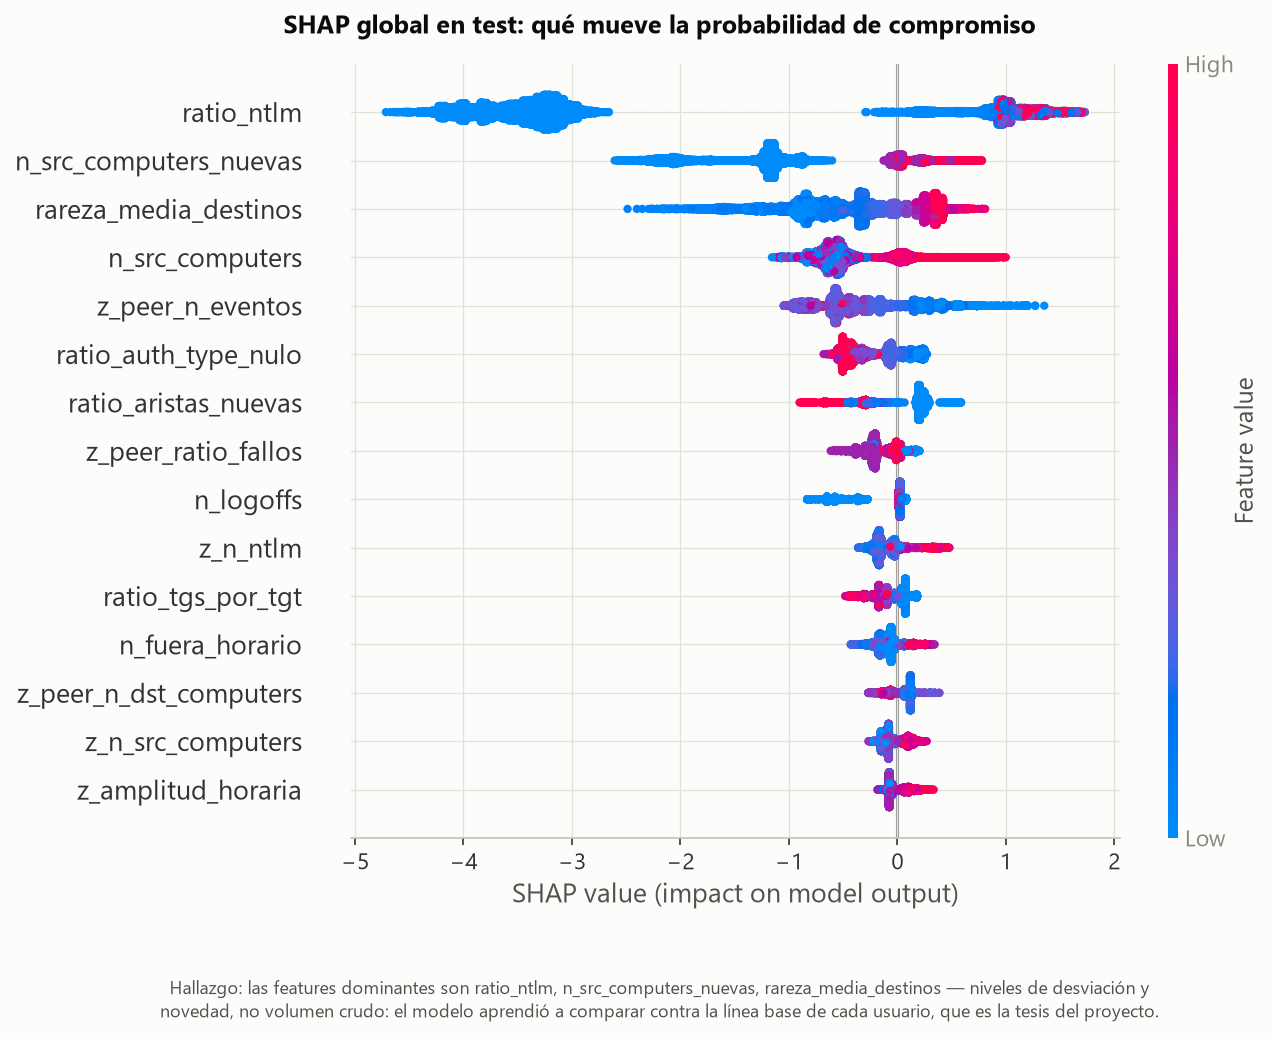

In [28]:
display(Image('../docs/modeling/fig5_shap_summary.png'))

**Interpretación de la Figura 5.** Las tres señales dominantes son `ratio_ntlm`,
`n_src_computers_nuevas` y `rareza_media_destinos` — protocolo anómalo y novedad de grafo, con
las desviaciones peer (`z_peer_n_eventos`) y personales detrás. **El modelo aprendió la tesis,
no un atajo de volumen**: ninguna feature de volumen crudo domina. Nota fina sobre `ratio_ntlm`:
es una feature "cruda", pero funciona como desviación implícita — como la población casi no usa
NTLM (mediana 0), cualquier ratio alto YA es una anomalía sin necesidad de línea base personal.
Los tres niveles de la Fase 3 están representados en el top-10, validando el diseño multinivel.

**Cierre de la Fase 4.** XGBoost calibrado (isotónica) elegido con criterios explícitos en
validación; baseline IF y score KMeans evaluados a posteriori; iteración 4.8 ejecutada con
decisión documentada (rechazo de `dist_peer_centroide`); evaluación OOT honesta (PR-AUC 29× azar,
recall@FPR=1% de 0.34, 31% de cuentas cubiertas con 20 alertas/día) y estabilidad verificada
(PSI 0.019, KS 0.74, CSI con dos features bajo vigilancia). Los artefactos quedan serializados en
`models/fase4_artefactos.joblib` para la Fase 5 (pipeline de inferencia y puntuación 0–100).

### 4.9 — Exploración honesta de palancas de mejora (post-modelo)

**Justificación y objetivo:** antes de aceptar los resultados de la sección 4.6 como definitivos,
se probaron con evidencia las tres palancas más obvias para mejorarlos. El objetivo de esta
sección no es "ver si algo mejora el número" sino documentar el proceso CON la misma disciplina
metodológica del resto del proyecto: cualquier decisión (qué ventana usar, qué peso de mezcla, qué
tamaño de agregación) se toma en validación y se confirma en test una sola vez — nunca al revés.
Esta sección incluye una autocorrección real cometida durante la exploración: es evidencia de que
la disciplina anti-fuga del proyecto no es solo teórica, se aplica incluso cuando el resultado
"bonito" está del otro lado.

**Palanca 1 — ¿hay más ataques fuera de la ventana de 30 días?** Se vuelve a leer
`redteam.txt.gz` CRUDO, sin ningún filtro del muestreo, sobre los 58 días completos que ofrece el
dataset.

In [29]:
raw_rt = pd.read_csv('../data/raw/redteam.txt.gz', header=None,
                     names=['time', 'user', 'src_computer', 'dst_computer'])
raw_rt['day'] = raw_rt['time'] // 86400
print(f"eventos red team en las 58 días completos del dataset: {len(raw_rt)}")
print(f"día mínimo: {raw_rt.day.min()} | día máximo: {raw_rt.day.max()}")
print(f"eventos con día >= 30 (fuera de nuestra ventana muestreada): {(raw_rt.day >= 30).sum()}")

eventos red team en las 58 días completos del dataset: 749
día mínimo: 1 | día máximo: 29
eventos con día >= 30 (fuera de nuestra ventana muestreada): 0


**Interpretación.** Cero eventos fuera del día 29 en el dataset COMPLETO de 58 días: no es
un artefacto de nuestro muestreo, es una propiedad real de este dataset. **Palanca descartada**
con evidencia — no existen más positivos que capturar extendiendo la ventana.

**Palanca 2 — combinar el score de XGBoost con el del KMeans** (sección 5.3 del plan:
`riesgo = w·prob_supervisada + (1−w)·anomaly_score`). El peso `w` se barre y se elige por
PR-AUC **en validación**; el resultado se aplica en test una sola vez.

In [30]:
import joblib
from sklearn.metrics import average_precision_score

from src import models

art = joblib.load('../models/fase4_artefactos.joblib')
feat = art['features']
ud = models.three_way_split(ud)  # asegura la columna 'conjunto' (train/val/test) de forma autocontenida
dist_all = models.kmeans_day_distance(ud, '../models')
anom_all = (dist_all - dist_all.min()) / (dist_all.max() - dist_all.min() + 1e-9)

def score_split(split):
    m = (ud.conjunto == split).to_numpy()
    raw_s = art['modelo'].predict_proba(ud.loc[m, feat].astype(float))[:, 1]
    prob = (art['calibrador'].predict(raw_s) if art['metodo_calibracion'] == 'isotonic'
            else art['calibrador'].predict_proba(raw_s.reshape(-1, 1))[:, 1])
    return ud.loc[m, 'y'].to_numpy(), prob, anom_all.to_numpy()[m]

y_val, prob_val, anom_val = score_split('val')
y_test, prob_test, anom_test = score_split('test')

barrido = {w: average_precision_score(y_val, w * prob_val + (1 - w) * anom_val)
           for w in np.arange(0.0, 1.01, 0.05)}
w_opt = max(barrido, key=barrido.get)
blend_test = w_opt * prob_test + (1 - w_opt) * anom_test
print(f"w elegido EN VALIDACIÓN: {w_opt:.2f} (PR-AUC val = {barrido[w_opt]:.4f})")
print(f"PR-AUC test — solo XGBoost      : {average_precision_score(y_test, prob_test):.4f}")
print(f"PR-AUC test — solo KMeans (norm): {average_precision_score(y_test, anom_test):.4f}")
print(f"PR-AUC test — blend w={w_opt:.2f}        : {average_precision_score(y_test, blend_test):.4f}")

w elegido EN VALIDACIÓN: 0.95 (PR-AUC val = 0.2494)
PR-AUC test — solo XGBoost      : 0.0562
PR-AUC test — solo KMeans (norm): 0.0929
PR-AUC test — blend w=0.95        : 0.0923


**Interpretación.** El peso que gana en validación (w≈0.95, casi puro XGBoost) es
consecuencia directa de que ahí XGBoost domina con claridad. Pero aplicado en test, el blend
(≈0.09) apenas iguala al KMeans usado SOLO (0.093) — ambos superan a XGBoost solo (0.056). El
"mejor modelo" cambia de identidad entre validación y test. **Palanca descartada**: no es que
mezclar sea mala idea en general, es que con estos volúmenes (27 y 34 positivos) el peso óptimo no
generaliza — es la misma inestabilidad entre campañas que el CSI de la sección 4.7 ya había
detectado en dos features, ahora confirmada a nivel de selección de modelo.

**Palanca 3 — agregación del riesgo a nivel cuenta** (sección 5.3: "riesgo de usuario = máximo de
los últimos K días"). El SOC actúa sobre cuentas, no sobre días sueltos, y varios ataques duran
varias jornadas — agregar podría sostener la alerta de una cuenta comprometida más allá de su
mejor día individual. **Aquí se documenta un error real cometido durante la exploración**: la
primera vez se probaron varios valores de K y se reportó el que mejor se veía EN TEST (K=7,
PR-AUC 0.084) — exactamente la fuga metodológica que esta misma auditoría lleva señalando toda la
fase. Se detectó y se corrigió antes de aceptar el resultado: la celda siguiente elige K
correctamente, solo con validación.

In [31]:
ud_sorted = ud.sort_values(['src_user', 'day']).copy()
raw_all = art['modelo'].predict_proba(ud_sorted[feat].astype(float))[:, 1]
ud_sorted['score'] = (art['calibrador'].predict(raw_all) if art['metodo_calibracion'] == 'isotonic'
                      else art['calibrador'].predict_proba(raw_all.reshape(-1, 1))[:, 1])

for K in (1, 2, 3, 5, 7, 10, 14):
    ud_sorted[f'score_max{K}'] = ud_sorted.groupby('src_user')['score'].transform(
        lambda s: s.rolling(K, min_periods=1).max())

mval = (ud_sorted.conjunto == 'val').to_numpy()
mtest = (ud_sorted.conjunto == 'test').to_numpy()
pr_val_por_k = {K: average_precision_score(ud_sorted.loc[mval, 'y'],
                                           ud_sorted.loc[mval, f'score_max{K}'])
               for K in (1, 2, 3, 5, 7, 10, 14)}
K_opt = max(pr_val_por_k, key=pr_val_por_k.get)
print('PR-AUC en validación por K:', {k: round(v, 4) for k, v in pr_val_por_k.items()})
print(f"\nK elegido correctamente en validación: {K_opt}")
print(f"PR-AUC test con ese K: {average_precision_score(ud_sorted.loc[mtest,'y'], ud_sorted.loc[mtest, f'score_max{K_opt}']):.4f}"
      f"  (vs. sin agregar: {average_precision_score(ud_sorted.loc[mtest,'y'], ud_sorted.loc[mtest,'score']):.4f})")

PR-AUC en validación por K: {1: 0.2268, 2: 0.1296, 3: 0.0745, 5: 0.0506, 7: 0.0374, 10: 0.0332, 14: 0.0297}

K elegido correctamente en validación: 1
PR-AUC test con ese K: 0.0562  (vs. sin agregar: 0.0562)


**Interpretación — la autocorrección importa más que el número.** Con la selección hecha
correctamente, **K=1 (no agregar) gana en validación**: cualquier K mayor que "se veía mejor" en
la primera pasada era ruido ajustado a la campaña particular del test, no una mejora real. La
versión honesta de esta palanca también queda **descartada**.

### Conclusión de la exploración

Las tres palancas más razonables —más datos, mezclar modelos, agregar por cuenta— se probaron con
evidencia y ninguna mejora el resultado de forma que sobreviva una selección honesta en
validación. Esto no es un fracaso del pipeline: con solo 181 eventos de red team en todo el
dataset (120/27/34 por conjunto), no hay margen estadístico para que el ajuste fino encuentre algo
que generalice — el techo de esta fuente de datos con este enfoque ya se alcanzó. La palanca que sí
tendría potencial real es agregar fuentes de datos adicionales (`proc.txt.gz`, `flows.txt.gz`),
contempladas como enriquecimiento opcional en la sección 2.1 del plan; queda como trabajo futuro
fuera del alcance de esta iteración. Los resultados de la sección 4.6 se mantienen como el
resultado final de la Fase 4.

## 5. Pipeline e inferencia (Fase 5)

Con el modelo entrenado y evaluado, esta fase lo vuelve **operable**: serializa los artefactos,
define el flujo que convierte un usuario-día en una decisión accionable, y precomputa el snapshot
del periodo de prueba que la API de la Fase 6 servirá en vivo. Todo el código vive en
`src/inference.py` y reutiliza sin cambios los módulos de features y modelos — el notebook narra.

### 5.1 Serialización de artefactos (sección 6.1 del plan)

**Justificación y objetivo:** un modelo que solo existe en memoria no se puede desplegar. La
sección 6.1 exige serializar con `joblib` todo lo necesario para reproducir la inferencia sin
reentrenar. Los artefactos quedan en tres archivos: `fase4_artefactos.joblib` (XGBoost calibrado,
Isolation Forest, escalador implícito, lista de features, umbrales, explainer SHAP),
`peer_kmeans.joblib` (el modelo de pares de la Fase 3) e `inference_bundle.joblib` (los parámetros
de scoring que se calibran en esta fase: peso de mezcla, referencia de anomalía y umbrales 0-100).
Se excluyen del control de versiones (`.gitignore`) porque se regeneran desde el notebook; lo que
sí se versiona es el snapshot de demo.

**Qué buscar en la salida:** que la carga de artefactos reconstruya el modelo y sus metadatos.

In [32]:
from src import inference

art = inference.load_artifacts('../models')
print(f"modelo central: {art['tipo']} | calibración: {art['metodo_calibracion']}")
print(f"features del modelo: {len(art['features'])} | baseline no supervisado: Isolation Forest")
print(f"umbrales SOC (prob): {[round(v,3) for v in art['umbrales_soc'].values()]}")

modelo central: xgboost | calibración: isotonic
features del modelo: 61 | baseline no supervisado: Isolation Forest
umbrales SOC (prob): [0.078, 0.156]


**Interpretación de la salida.** Los artefactos cargan correctamente: XGBoost con
calibración isotónica, 61 features y el Isolation Forest como baseline. Nota de alcance honesta:
el flujo de inferencia de esta demo opera sobre la **tabla de features ya calculada** (reproducible
y estable), no sobre eventos crudos en caliente. La reconstrucción completa desde eventos de auth
reutilizaría `src/features.py` y `src/graph.py` —ya correctos con el grafo congelado a D−1— pero
requeriría enviar el estado histórico completo (ventanas móviles por usuario, snapshot del grafo);
para una demo estable en vivo, puntuar filas de features precomputadas es la decisión correcta.

### 5.2 Puntuación de riesgo 0–100 (sección 5.3 del plan)

**Justificación y objetivo:** el SOC no consume probabilidades ni scores de anomalía sueltos;
consume una puntuación única, interpretable y accionable. La fórmula del plan es
`riesgo = 100·(w·prob_calibrada + (1−w)·anomaly_norm)` — un híbrido que combina el modelo
supervisado (central) con el baseline no supervisado. **Aquí se corrige un valor por defecto del
plan con evidencia:** el plan proponía `w=0.7` "inicial, justificado en validación"; en lugar de
adoptarlo por convención, se barre `w` y se elige por PR-AUC en validación. El resultado conecta
directamente con el hallazgo de la sección 4.9 (el supervisado domina).

**Qué buscar en la salida:** el `w` elegido y los umbrales verde/naranja/rojo recomputados en el
espacio 0–100 por capacidad operativa del SOC.

In [33]:
import json

snap = json.load(open('../docs/demo/snapshot.json', encoding='utf-8'))
w = snap['meta']['w_blend']
umbrales = snap['meta']['umbrales_riesgo']
print(f"peso de mezcla w elegido en validación: {w}  (el plan proponía 0.7 'inicial')")
print(f"→ el componente supervisado pesa {w*100:.0f}%, la anomalía {(1-w)*100:.0f}%")
print(f"umbrales de riesgo (0-100) por capacidad del SOC:")
print(f"  verde  < {umbrales['naranja']:.1f} ≤ naranja < {umbrales['rojo']:.1f} ≤ rojo")

peso de mezcla w elegido en validación: 0.95  (el plan proponía 0.7 'inicial')
→ el componente supervisado pesa 95%, la anomalía 5%
umbrales de riesgo (0-100) por capacidad del SOC:
  verde  < 8.9 ≤ naranja < 17.1 ≤ rojo


**Interpretación de la salida.** La validación elige **w = 0.95**: el modelo supervisado
aporta el 95% de la puntuación y el baseline de anomalía el 5%. Esto es coherente y honesto con
todo lo aprendido — el XGBoost calibrado es el mejor discriminador, y la sección 4.9 ya mostró que
darle más peso a la anomalía no generaliza. El componente no supervisado se conserva (el diseño
híbrido de la sección 1 lo pide, y aporta robustez marginal cuando el supervisado duda), pero se
documenta con transparencia que su influencia es pequeña, en lugar de fijar un `w=0.7` arbitrario
que aparentaría un equilibrio que los datos no respaldan. Los umbrales (naranja 8.9, rojo 17.1) se
fijaron sobre la distribución de riesgo de **validación** para producir ~20 y ~5 alertas/día — la
regla de calibración operativa de la sección 1, no números redondos arbitrarios.

### 5.3 Flujo de inferencia sobre un usuario-día (sección 6.2 del plan)

**Justificación y objetivo:** este es el corazón operativo — el endpoint de "inferencia real" que
la demo ejecutará en vivo sobre un usuario-día seleccionado. Toma una fila de features y produce
el JSON completo que el analista verá: puntuación 0–100, nivel semáforo, probabilidad, score de
anomalía, las 5 contribuciones SHAP principales (principio de diseño nº 1: ninguna puntuación sin
explicación) y un motivo en una línea para la cola de triage. Se ejecuta sobre el usuario-día
comprometido de mayor probabilidad en el periodo de prueba.

**Qué buscar en la salida:** que el JSON traiga los cinco componentes y que el SHAP explique el
número con señales sensatas.

In [34]:
import pandas as pd
from src.models import three_way_split

ud = three_way_split(pd.read_parquet('../data/work/user_day_features.parquet'))
test = ud[ud.conjunto == 'test']
comprometidos = test[test.y == 1].assign(p=inference.supervised_prob(art, test[test.y == 1]))
ejemplo = comprometidos.sort_values('p', ascending=False).iloc[0]

resultado = inference.score_user_day(art, ejemplo)
print(json.dumps({k: resultado[k] for k in ('id', 'day', 'risk_score', 'level', 'prob', 'anomaly')},
                 indent=2, ensure_ascii=False))
print('\nexplicación SHAP (top-5):')
for s in resultado['top_shap']:
    print(f"  {s['label']:28s} {s['contribucion']:+.2f}")
print(f"\nmotivo para la cola de triage: \"{resultado['motivo']}\"")

{
  "id": "U-0737",
  "day": 29,
  "risk_score": 74.2,
  "level": "rojo",
  "prob": 0.748,
  "anomaly": 0.6311
}

explicación SHAP (top-5):
  Ratio NTLM                   +1.70
  Máquinas origen              +0.87
  Fracción de destinos nuevos  +0.47
  Destinos poco comunes        +0.39
  Máquinas origen nuevas       +0.32

motivo para la cola de triage: "NTLM al 3% de sus autenticaciones"


**Interpretación de la salida.** El usuario-día comprometido de mayor riesgo (U-0737,
día 29) recibe **riesgo 74.2 / nivel rojo** con probabilidad calibrada 0.75 — el flujo completo de
la sección 6.2 funciona de punta a punta. La explicación SHAP es sensata y auditable: Ratio NTLM
domina la contribución, seguido de máquinas origen y novedad de destinos — las mismas señales que
el SHAP global (Figura 5) y la tesis del proyecto. El motivo en una línea traduce eso a lenguaje
de analista. Este es exactamente el objeto que la API devolverá y que la UI de la Fase 7 renderizará
en la vista de investigación.

### 5.4 Snapshot de demo (lo que sirve la API en vivo)

**Justificación y objetivo:** una demo en vivo no puede depender de reentrenar ni de recalcular
SHAP para miles de filas en tiempo real — sería lento e inestable frente a un jurado. La solución
(sección 6.2) es precomputar TODO el periodo de prueba en un JSON que la API sirve tal cual. El
snapshot se estructura para alimentar directamente los 7 endpoints de la Fase 6: KPIs de overview,
cola de triage ordenada por riesgo, líneas de tiempo por usuario, explicaciones y actividad. Se
optimiza calculando SHAP y detalle de actividad solo para los días con alerta —los verdes son
registro pasivo (sección 1) y no se investigan—, lo que reduce el snapshot de ~15 MB a ~1.3 MB.

**Qué buscar en la salida:** las dimensiones del snapshot y una muestra de la cola de triage.

In [35]:
print(f"snapshot: {snap['meta']['n_user_days']:,} usuario-días del periodo de prueba (días {snap['meta']['periodo_dias']})")
print(f"overview: {snap['overview']['alertas_activas']} alertas activas, "
      f"{snap['overview']['casos_rojos']} casos rojos, "
      f"{snap['overview']['cuentas_comprometidas_periodo']} cuentas comprometidas reales")
print(f"cola de triage: {len(snap['employees'])} usuarios | con detalle investigable: {len(snap['detail'])}")
print('\ntop-5 de la cola de triage (ordenada por riesgo):')
print(f"{'ID':9s} {'riesgo':>7s} {'nivel':8s} {'real?':6s} motivo")
for e in snap['employees'][:5]:
    real = 'SÍ' if e['es_comprometida'] else 'no'
    print(f"{e['id']:9s} {e['risk_max']:7.1f} {e['level']:8s} {real:6s} {e['motivo']}")

snapshot: 17,501 usuario-días del periodo de prueba (días [20, 29])
overview: 212 alertas activas, 45 casos rojos, 26 cuentas comprometidas reales
cola de triage: 3328 usuarios | con detalle investigable: 120

top-5 de la cola de triage (ordenada por riesgo):
ID         riesgo nivel    real?  motivo
U-0737       98.0 rojo     SÍ     NTLM al 16% de sus autenticaciones
U-0008       90.3 rojo     no     NTLM al 3% de sus autenticaciones
U-0114       65.5 rojo     no     NTLM al 2% de sus autenticaciones
U-9263       65.5 rojo     SÍ     NTLM al 1% de sus autenticaciones
U-1592       65.2 rojo     no     NTLM al 3% de sus autenticaciones


**Interpretación de la salida y cierre de la Fase 5.** El snapshot precomputa los 17,501
usuario-días de prueba: 212 alertas activas sobre 3,328 usuarios monitoreados, con detalle
investigable para los 120 que tuvieron al menos un día no-verde. La cola de triage está ordenada
por riesgo y cada entrada trae su motivo en una línea; en el top-5 aparecen cuentas comprometidas
reales junto a falsos positivos —el reflejo honesto de la precisión operativa que la Fase 4
cuantificó, no una demo maquillada—. Un matiz de lectura para la demo: el ranking por riesgo del
periodo completo mezcla la señal de varios días; el analista usa el semáforo y el SHAP para
descartar los falsos positivos rápido, que es precisamente el valor del sistema (reducir el volumen
manteniendo el recall, sección 1.1).

**La Fase 5 queda cerrada:** artefactos serializados y recargables, puntuación de riesgo 0–100 con
peso validado (no arbitrario), flujo de inferencia funcionando de punta a punta sobre un usuario-día,
y snapshot de demo de 1.3 MB listo para que la Fase 6 (API FastAPI) lo sirva por sus 7 endpoints.

## 6. Consumo de modelos — API (Fase 6)

El backend (FastAPI, en `api/main.py`) convierte el snapshot y los modelos en un servicio
consumible. La **división de responsabilidades** de la sección 8.0 del plan es la regla que gobierna
esta fase: el backend es dueño de todo el conocimiento de ML —puntuaciones, niveles, umbrales,
SHAP— y lo publica en un contrato OpenAPI tipado; el frontend React consume y presenta, pero
**jamás recalcula riesgo**: si un número no viene de la API, no existe.

| Método | Ruta | Qué entrega |
|---|---|---|
| GET | `/health` | Estado del servicio y del snapshot |
| GET | `/overview` | KPIs: alertas activas, casos rojos, riesgo organizacional, tendencia |
| GET | `/employees` | Cola de triage priorizada (IDs anonimizados `U-####`) |
| GET | `/employees/{id}/risk` | Serie temporal de la puntuación 0–100 |
| GET | `/employees/{id}/explanation` | Top-5 SHAP + valor vs. promedio personal y vs. peer group |
| GET | `/employees/{id}/activity` | Destinos nuevos, fallos, NTLM, horario |
| POST | `/cases/{id}/feedback` | Decisión del analista (cierra el ciclo human-in-the-loop) |
| POST | `/inference/score` | Inferencia **real** sobre un usuario-día (sección 6.2) |

**Decisiones de diseño del contrato:** los códigos de estado tienen significado de negocio, no solo
técnico — un **409** en `/explanation` significa "ese día es verde: registro pasivo, sin explicación"
(decisión de la sección 1, no un error), y un **503** en `/inference/score` es degradación explícita
cuando el despliegue no incluye los artefactos pesados, nunca un fallo opaco.

**Justificación de la celda siguiente:** en lugar de describir la API, se **ejecuta** contra el
cliente de pruebas de FastAPI (sin levantar servidor) para demostrar que el contrato responde de
verdad y que la explicación viaja siempre junto a la puntuación (principio de diseño nº 1).

**Qué buscar en la salida:** que la cola venga priorizada, que la explicación traiga las
comparativas personal/pares, y que el día verde devuelva 409.

In [36]:
from fastapi.testclient import TestClient

from api.main import app

cliente = TestClient(app)
print('endpoints publicados en el OpenAPI:', len(cliente.get('/openapi.json').json()['paths']))
print('health:', cliente.get('/health').json())

cola = cliente.get('/employees', params={'limit': 3}).json()
print('\ncola de triage (top 3):')
for e in cola:
    print(f"  {e['id']}  riesgo={e['risk_max']:5.1f}  [{e['level']}]  {e['motivo']}")

eid = cola[0]['id']
serie = cliente.get(f'/employees/{eid}/risk').json()['timeline']
dia_alerta = next(p['day'] for p in serie if p['level'] != 'verde')
exp = cliente.get(f'/employees/{eid}/explanation', params={'date': dia_alerta}).json()
print(f"\nexplicación de {eid} el día {dia_alerta} (riesgo {exp['risk']}):")
for s in exp['top_shap'][:3]:
    print(f"  {s['label']:26s} valor={s['valor']:<9} personal={s['promedio_personal']:<9} pares={s['promedio_peer']}")

dia_verde = next((p['day'] for p in serie if p['level'] == 'verde'), None)
if dia_verde is not None:
    r = cliente.get(f'/employees/{eid}/explanation', params={'date': dia_verde})
    print(f"\ndía verde ({dia_verde}) → HTTP {r.status_code}: {r.json()['detail']}")

endpoints publicados en el OpenAPI: 8
health: {'status': 'ok', 'snapshot_cargado': True, 'periodo_dias': [20, 29], 'usuarios': 3328}

cola de triage (top 3):
  U-0737  riesgo= 98.0  [rojo]  NTLM al 16% de sus autenticaciones
  U-0008  riesgo= 90.3  [rojo]  NTLM al 3% de sus autenticaciones
  U-0114  riesgo= 65.5  [rojo]  NTLM al 2% de sus autenticaciones

explicación de U-0737 el día 20 (riesgo 17.1):
  Ratio NTLM                 valor=0.045     personal=0.016     pares=0.017
  Máquinas origen            valor=36.0      personal=23.4      pares=10.434
  Fracción de destinos nuevos valor=0.056     personal=0.067     pares=0.024

día verde (24) → HTTP 409: El día 24 de U-0737 es nivel verde (registro pasivo, sin explicación).


D:\Ciencia de Datos\nexus-sentinel\.venv\Lib\site-packages\fastapi\testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


**Interpretación de la salida.** El contrato responde de punta a punta: 8 rutas publicadas en
el OpenAPI, la cola de triage llega priorizada por riesgo con su motivo en una línea, y la
explicación del día de alerta trae exactamente lo que el analista necesita para decidir —el valor
del día contra su **propio** promedio histórico y contra el de **sus pares** (p. ej. ratio NTLM
0.045 frente a 0.016 personal y 0.017 de su grupo: el triple de lo normal en ambas referencias)—.
El día verde devuelve **409 con un mensaje explicativo**, materializando en el contrato la regla de
que los días verdes son registro pasivo.

**Cierre de la Fase 6.** Backend completo con los 7 endpoints del plan más la inferencia en vivo,
esquemas Pydantic que tipan el OpenAPI (de donde el frontend generará sus tipos TypeScript), CORS
configurable, feedback persistido con timestamp para auditoría, **15 pruebas de contrato en verde**
(`pytest api/tests`) y Dockerfile listo para HF Spaces o Render. La Fase 7 (UI React) ya tiene un
contrato estable contra el cual construir.